# <span style="font-size:25px; color:black">SETUP</span>

Create the virtual environment and install all the necessary libraries.

# <span style="font-size:25px; color:Blue">IMPORT LIBRARIES</span>

In [ ]:
import warnings
import sys
import os
import time

os.environ["OMP_NUM_THREADS"] = "20"
os.environ["OPENBLAS_NUM_THREADS"] = "20"
os.environ["MKL_NUM_THREADS"] = "20"
os.environ["NUMEXPR_NUM_THREADS"] = "20"

# To silence the warnings
warnings.filterwarnings("ignore")
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
warnings.simplefilter("ignore", SyntaxWarning)
warnings.simplefilter("ignore", DeprecationWarning)
warnings.simplefilter("ignore", ImportWarning)

sys.stderr = open(os.devnull, 'w')

# To hide the warnings

In [2]:
from IPython.display import Javascript

Javascript("""
require(['base/js/events'], function(events) {
  function collapseTaggedMarkdown(){
    Jupyter.notebook.get_cells().forEach(function(cell){
      if (cell.cell_type === 'markdown' &&
          cell.metadata.tags && cell.metadata.tags.indexOf('nota') > -1) {
        // Oculta el render y muestra el editor (plegado visual)
        cell.element.find('div.text_cell_render').hide();
        cell.element.find('div.input').show();
      }
    });
  }
  events.on('notebook_loaded.Notebook', collapseTaggedMarkdown);
  if (Jupyter.notebook._fully_loaded) collapseTaggedMarkdown();
});
""")

# === HELPER: Asignar colores personalizados:
def assign_custom_colors(adata, key, colors):
    """
    Asigna una lista de colores personalizada a una variable categórica en adata.obs.
    La cantidad de colores debe coincidir con el número de categorías únicas.
    """
    unique_cats = adata.obs[key].unique().tolist()
    if len(colors) != len(unique_cats):
        raise ValueError(f"Se esperaban {len(unique_cats)} colores para '{key}', pero se recibieron {len(colors)}.")
    adata.uns[key + "_colors"] = colors

# === HELPER: para usar en cualquier celda
def task_done_beep():
    from IPython.display import Audio, display
    import numpy as np
    framerate = 44100
    duration = 0.75
    freq = 660
    t = np.linspace(0, duration, int(framerate * duration))
    wave = 0.5 * np.sin(2 * np.pi * freq * t)
    display(Audio(wave, rate=framerate, autoplay=True))

# Al final de cualquier celda
task_done_beep()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.sparse
from scipy.sparse import csr_matrix
import networkx as nx

import pickle
import time
from joblib import Parallel, delayed
from tqdm import tqdm

import anndata as ad
import scanpy as sc
import scanpy.external as sce
#import doubletdetection #solo por tener un segundo metodos de deteccion de dobletes (Recuerda Solo de scvitools)
import celltypist
from celltypist import models
import scib
from itertools import combinations
from scipy import io
from scipy import sparse
from scipy.stats import median_abs_deviation as mad
from sklearn.metrics import normalized_mutual_info_score, silhouette_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    adjusted_rand_score,
    adjusted_mutual_info_score,
    normalized_mutual_info_score,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from IPython.display import Audio, display
import numpy as np

import winsound

def task_done_beep():
    winsound.Beep(440, 200)

from rpy2.robjects import pandas2ri, r
import rpy2.robjects as ro
import rpy2.robjects.numpy2ri as numpy2ri
import anndata2ri


task_done_beep()

In [ ]:


import pickle
import time
from itertools import combinations


import numpy as np
import pandas as pd
import scipy.sparse
from scipy import io, sparse
from scipy.sparse import csr_matrix
from scipy.stats import median_abs_deviation as mad


import matplotlib.pyplot as plt
import seaborn as sns


import networkx as nx


from joblib import Parallel, delayed
from tqdm import tqdm


import anndata as ad
import scanpy as sc
import scanpy.external as sce
import scvi

from scvi.model import SCVI, SCANVI


import harmonypy
import harmonypy as hm
from harmony import harmonize
import scanorama
import scib #This is the old one
import scib.metrics as sm #This is the new one

from scib.metrics import metrics_all
from scib_metrics.benchmark import Benchmarker
from scib_metrics.benchmark import BioConservation, BatchCorrection


import celltypist
from celltypist import models


from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    adjusted_rand_score,
    adjusted_mutual_info_score,
    normalized_mutual_info_score,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)


import h5py


from IPython.display import Audio, display


import anndata2ri
import rpy2.robjects as ro

from rpy2.robjects import pandas2ri, r
import rpy2.robjects.numpy2ri as numpy2ri


%matplotlib inline


def task_done_beep():
    framerate = 44100
    t = np.linspace(0, 0.2, int(framerate * 0.2))
    data = np.sin(2 * np.pi * 440 * t)
    display(Audio(data, rate=framerate, autoplay=True))


task_done_beep()

# <span style="font-size:25px; color:blue">Construct Anndata From R to PYTHON (h5ad)</span></br> <span style="font-size:16px; color:blue"> Generate an anndata object from the matrix files</span> 

In [ ]:
# Directorios
matrix_dir = "D:/TFG/Anndatas_noncoding"      # Folder with the files generated by R
h5ad_dir   = "D:/TFG/h5ad_files_noncoding"        # Folder where the h5ad will be stored

# Ensure that the output directory exists
os.makedirs(h5ad_dir, exist_ok=True)

<span style="font-size:18px; color:blue"> Colectively (h5ad)</span></br>

In [ ]:
# Read the CSV file containing the files list generated in R
files_list_path = os.path.join(matrix_dir, "files_list.csv")
files_list = pd.read_csv(files_list_path) # Iterate over each register (each Seurat object)
for idx, row in files_list.iterrows():
    object_name = row['object_name']          # For example: "seurat_GSM5514787"
    object_folder = row['object_folder']        # For example: "GSM5514787"
    matrix_filename = row['matrix_file']        # For example: "GSM5514787/matrix.mtx"
    metadata_filename = row['metadata_file']    # For example: "GSM5514787/metadata.csv"
    gene_names_filename = row['gene_names_file'] # For example: "GSM5514787/gene_names.csv"
    
    # Build the filepath of the matrix
    matrix_path = os.path.join(matrix_dir, matrix_filename)
    
    # Build the filepaths for metadata and gene names
    metadata_path = os.path.join(matrix_dir, metadata_filename)
    gene_names_path = os.path.join(matrix_dir, gene_names_filename)
    
    print(f"Procesando {object_name}...")
    
    # Read the matrix (in format mtx) and transpose it
    X = io.mmread(matrix_path)
    X = X.transpose().tocsr()  # Ahora: filas = células, columnas = genes
    
    # Create the AnnData object
    adata = ad.AnnData(X=X)
    
    # Read the metadata
    metadata = pd.read_csv(metadata_path)
    adata.obs = metadata.copy()
    
    # Use the 'barcode' column as the index if existing
    if 'barcode' in adata.obs.columns:
        adata.obs.index = adata.obs['barcode']
    else:
        print(f"Advertencia: No se encontró columna 'barcode' en la metadata de {object_name}.")
    
    # Read the gene names and asssign them to adata.var.index
    with open(gene_names_path, 'r') as f:
        gene_names = f.read().splitlines()
    adata.var.index = gene_names
        
    # Save the AnnData object in h5ad format in the output folder
    output_filename = f"{object_name}.h5ad"
    output_path = os.path.join(h5ad_dir, output_filename)
    adata.write(output_path)
    
    print(f"Guardado {object_name} en {output_filename}")

print("✅ Proceso finalizado.")

Procesando seurat_GSM5514787...
Guardado seurat_GSM5514787 en seurat_GSM5514787.h5ad
Procesando seurat_GSM5514788...
Guardado seurat_GSM5514788 en seurat_GSM5514788.h5ad
Procesando seurat_GSM5514789...
Guardado seurat_GSM5514789 en seurat_GSM5514789.h5ad
Procesando seurat_GSM5514790...
Guardado seurat_GSM5514790 en seurat_GSM5514790.h5ad
Procesando seurat_GSM5514791...
Guardado seurat_GSM5514791 en seurat_GSM5514791.h5ad
Procesando seurat_GSM5514792...
Guardado seurat_GSM5514792 en seurat_GSM5514792.h5ad
Procesando seurat_GSM5514793...
Guardado seurat_GSM5514793 en seurat_GSM5514793.h5ad
Procesando seurat_GSM5514794...
Guardado seurat_GSM5514794 en seurat_GSM5514794.h5ad
✅ Proceso finalizado.


<span style="font-size:18px;color:Chocolate">Test to confirm that all the objects were processed correctly</span> 

In [4]:
os.chdir("D:\TFG\h5ad_files_coding")
adata_prueba = sc.read_h5ad("seurat_GSM5514787.h5ad")
adata_prueba.obs.head()

,orig.ident,nCount_RNA,nFeature_RNA,DoubletClass,DoubletScore,barcode
barcode,,,,,,
ATCGTAGGTAGTGTGG,GSM5514787,40681,6353,singlet,0.001010,ATCGTAGGTAGTGTGG
CCCTCTCAGCCTATTG,GSM5514787,40590,7172,doublet,0.998499,CCCTCTCAGCCTATTG
GCAACCGGTGCACATT,GSM5514787,35791,7864,singlet,0.006644,GCAACCGGTGCACATT
ATCGTGAGTGGAAATT,GSM5514787,35494,6343,singlet,0.036332,ATCGTGAGTGGAAATT
ATGAGGGAGGATTCCT,GSM5514787,34925,6162,singlet,0.034257,ATGAGGGAGGATTCCT


# <span style="font-size:32px; color:blue">QC</i></span> 
* <span style="font-size:16px; color:blue">Sample loading. Sample selection</i></span>
* <span style="font-size:16px; color:blue">Sample analysis</i></span>
* <span style="font-size:16px; color:blue">When there is a high number of h5 files to be compared, all the samples are aggregated together in a list in order to compare the QC all together</i></span>
* <span style="font-size:16px; color:blue">List the files that end in 'filtered.h5' after scDblFinder</i></span>

<span style="font-size:18px; color:red">*RECOVERY POINT*</i></span> <span style="font-size:12px; color:salmon">Read the files generated</i></span>

<span style="font-size:16px; color:blue">Before anything else, the filenames must be manually changed according to the conditions established in the GSE181955</i></span>

In [ ]:
# Directorio donde se encuentran los archivos h5ad generados por R y sometido a scrublet
directory = 'D:\TFG\h5ad_files_noncoding'

# Listar todos los archivos que terminen en '.h5ad'
files = [x for x in os.listdir(directory) if x.endswith('.h5ad') and x.startswith('seurat_')]
print("Archivos encontrados:", files)

# Contar el número de archivos
num_files_total = len(files)
print(f"Número total de archivos h5ad: {num_files_total}")

Archivos encontrados: ['seurat_GSM5514787_control.h5ad', 'seurat_GSM5514788_omt.h5ad', 'seurat_GSM5514789_omt.h5ad', 'seurat_GSM5514790_omt.h5ad', 'seurat_GSM5514791_omt.h5ad', 'seurat_GSM5514792_tumor.h5ad', 'seurat_GSM5514793_tumor.h5ad', 'seurat_GSM5514794_tumor.h5ad']
Número total de archivos h5ad: 8


In [6]:
# ✅ USAR ESTA CELDA
def load_it(adata_file):
    # Remover la extensión para extraer metadatos del nombre
    print(adata_file)
    base_name = adata_file.replace('.h5ad', '')
    base_name = base_name.replace('seurat_', '')
    print(base_name)

    # Asumimos que el nombre sigue la estructura:
    # Seurat_GSM7474501_control.h5ad  → samp = GSM5514787, cond = Control
    # Ajusta el split según la convención de nombres que tengas.
    parts = base_name.split('_')
    if len(parts) < 2:
        raise ValueError("El nombre del archivo no tiene el formato esperado: " + adata_file)
    samp = parts[0]  # GSM5514787
    cond = parts[-1]  # El último elemento, 'Control
    print(samp)
    print(cond)

    file_path = os.path.join(directory, adata_file)
    # Leer el archivo usando sc.read_h5ad (ya que todos son h5ad)
    adata = sc.read_h5ad(file_path)
 
    # Eliminar la columna 'barcode' si existe
    adata.obs.drop(columns=['barcode'], inplace=True, errors='ignore')

    # Agregar metadatos a la tabla de observaciones
    adata.obs['Sample'] = samp
    adata.obs['Condition'] = cond
    # Se actualiza el índice de cada célula para incluir información de la muestra
    adata.obs.index = adata.obs.index.astype(str) + '-' + samp + '_' + cond

    # Guardar el nombre del archivo como metadata adicional
    adata.uns['filename'] = adata_file
    adata.uns['file_path'] = file_path
    
    return adata

In [7]:
# ✅ USAR ESTA CELDA
# Cargar solo archivos 
files_h5ad = [f for f in files if f.startswith("seurat_GSM55147")] #Para que me cargue solo las muestras
print("Archivos:", files_h5ad)

# Contar el número de archivos
num_files = len(files_h5ad)
print(f"Número total de archivos h5ad: {num_files}")

adatas = [load_it(f) for f in files_h5ad]

print("Archivos cargados:")
for a in adatas:
    print(a.uns['filename'], a.shape)

Archivos: ['seurat_GSM5514787_control.h5ad', 'seurat_GSM5514788_omt.h5ad', 'seurat_GSM5514789_omt.h5ad', 'seurat_GSM5514790_omt.h5ad', 'seurat_GSM5514791_omt.h5ad', 'seurat_GSM5514792_tumor.h5ad', 'seurat_GSM5514793_tumor.h5ad', 'seurat_GSM5514794_tumor.h5ad']
Número total de archivos h5ad: 8
seurat_GSM5514787_control.h5ad
GSM5514787_control
GSM5514787
control
seurat_GSM5514788_omt.h5ad
GSM5514788_omt
GSM5514788
omt
seurat_GSM5514789_omt.h5ad
GSM5514789_omt
GSM5514789
omt
seurat_GSM5514790_omt.h5ad
GSM5514790_omt
GSM5514790
omt
seurat_GSM5514791_omt.h5ad
GSM5514791_omt
GSM5514791
omt
seurat_GSM5514792_tumor.h5ad
GSM5514792_tumor
GSM5514792
tumor
seurat_GSM5514793_tumor.h5ad
GSM5514793_tumor
GSM5514793
tumor
seurat_GSM5514794_tumor.h5ad
GSM5514794_tumor
GSM5514794
tumor
Archivos cargados:
seurat_GSM5514787_control.h5ad (4932, 32027)
seurat_GSM5514788_omt.h5ad (9049, 36929)
seurat_GSM5514789_omt.h5ad (4912, 38997)
seurat_GSM5514790_omt.h5ad (9274, 38250)
seurat_GSM5514791_omt.h5ad (7130,

In [ ]:
# To check that everything went right
adatas

[AnnData object with n_obs × n_vars = 4932 × 32027
     obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'DoubletClass', 'DoubletScore', 'Sample', 'Condition'
     uns: 'filename', 'file_path',
 AnnData object with n_obs × n_vars = 9049 × 36929
     obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'DoubletClass', 'DoubletScore', 'Sample', 'Condition'
     uns: 'filename', 'file_path',
 AnnData object with n_obs × n_vars = 4912 × 38997
     obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'DoubletClass', 'DoubletScore', 'Sample', 'Condition'
     uns: 'filename', 'file_path',
 AnnData object with n_obs × n_vars = 9274 × 38250
     obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'DoubletClass', 'DoubletScore', 'Sample', 'Condition'
     uns: 'filename', 'file_path',
 AnnData object with n_obs × n_vars = 7130 × 40185
     obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'DoubletClass', 'DoubletScore', 'Sample', 'Condition'
     uns: 'filename', 'file_path',
 AnnData object with n_obs × n

In [9]:
# ✅ USAR ESTA CELDA
def qc(adata):
    # Filtrar células con menos de 200 genes
    # sc.pp.filter_cells(adata, min_genes=200)
    # Esto no se hace porque ya se ha filtrado en seurat
    
    # Identificar genes mitocondriales, ribosomales y de hemoglobina
    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
    adata.var["hb"] = adata.var_names.str.contains(r"^HB(?!P)")
    
    
    # Calcular métricas de calidad
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True)
    
    # Se pueden eliminar métricas que no son necesarias
    # remove = ['total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 
            #   'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb']
    
    # Mantener solo las columnas relevantes
    # adata.obs = adata.obs[[x for x in adata.obs.columns if x not in remove]]
    
    return adata

In [10]:
# ✅ USAR ESTA CELDA
adatas_qc_list = [qc(ad) for ad in adatas]

In [ ]:
# To check the data
adatas_qc_list


[AnnData object with n_obs × n_vars = 4932 × 32027
     obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'DoubletClass', 'DoubletScore', 'Sample', 'Condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
     var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
     uns: 'filename', 'file_path',
 AnnData object with n_obs × n_vars = 9049 × 36929
     obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'DoubletClass', 'DoubletScore', 'Sample', 'Condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_r

In [12]:
adatas_qc_list[0].obs.head()


,orig.ident,nCount_RNA,nFeature_RNA,DoubletClass,DoubletScore,Sample,Condition,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,...,pct_counts_in_top_20_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb
barcode,,,,,,,,,,,,,,,,,,,,,
CCCTCTCAGCCTATTG-GSM5514787_control,GSM5514787,39408,7200,doublet,0.999920,GSM5514787,control,7200,8.881975,39408,...,14.052984,1396,7.242082,3.542428,7209,8.883224,18.293240,5,1.791759,0.012688
ATCGTAGGTAGTGTGG-GSM5514787_control,GSM5514787,39306,6224,singlet,0.000650,GSM5514787,control,6224,8.736329,39306,...,19.788327,2516,7.830823,6.401058,7566,8.931552,19.248970,1,0.693147,0.002544
GCAACCGGTGCACATT-GSM5514787_control,GSM5514787,37137,7869,singlet,0.012591,GSM5514787,control,7869,8.970813,37137,...,20.661335,4639,8.442470,12.491585,4898,8.496786,13.189003,2,1.098612,0.005385
ATCGTGAGTGGAAATT-GSM5514787_control,GSM5514787,33628,6219,singlet,0.004059,GSM5514787,control,6219,8.735525,33628,...,13.459022,1000,6.908755,2.973712,7036,8.858937,20.923040,3,1.386294,0.008921
ATGAGGGAGGATTCCT-GSM5514787_control,GSM5514787,33149,6033,singlet,0.002556,GSM5514787,control,6033,8.705165,33149,...,14.998944,1302,7.172425,3.927720,6672,8.805825,20.127304,5,1.791759,0.015083


In [13]:
adatas_qc_list[1].obs.head()

,orig.ident,nCount_RNA,nFeature_RNA,DoubletClass,DoubletScore,Sample,Condition,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,...,pct_counts_in_top_20_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb
barcode,,,,,,,,,,,,,,,,,,,,,
TCATCCGCACTGGACC-GSM5514788_omt,GSM5514788,90122,8700,singlet,0.009656,GSM5514788,omt,8700,9.071193,90122,...,13.815716,6517,8.782323,7.231309,15273,9.633907,16.947027,11,2.484907,0.012206
AGATGCTGTCAGGCAA-GSM5514788_omt,GSM5514788,84523,8536,singlet,0.014282,GSM5514788,omt,8536,9.052165,84523,...,12.122144,4314,8.369853,5.103936,16440,9.707533,19.450327,12,2.564949,0.014197
GTGCAGCAGAACGTGC-GSM5514788_omt,GSM5514788,63604,9663,singlet,0.315345,GSM5514788,omt,9663,9.176163,63604,...,18.072763,7780,8.959440,12.231935,6369,8.759355,10.013521,1,0.693147,0.001572
TTCGGTCAGGACGGAG-GSM5514788_omt,GSM5514788,61381,10397,singlet,0.030414,GSM5514788,omt,10397,9.249369,61381,...,11.690914,3562,8.178358,5.803099,8438,9.040619,13.746925,5,1.791759,0.008146
TTTACGTCAGCCCAGT-GSM5514788_omt,GSM5514788,52149,7056,singlet,0.011364,GSM5514788,omt,7056,8.861775,52149,...,13.716466,3193,8.069029,6.122840,7795,8.961366,14.947554,9,2.302585,0.017258


In [14]:
adatas_qc_list[7].obs.head()

,orig.ident,nCount_RNA,nFeature_RNA,DoubletClass,DoubletScore,Sample,Condition,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,...,pct_counts_in_top_20_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb
barcode,,,,,,,,,,,,,,,,,,,,,
GCCTGTTTCCGCAGTG-GSM5514794_tumor,GSM5514794,152043,13891,doublet,0.996433,GSM5514794,tumor,13891,9.539068,152043,...,18.552646,23461,10.063137,15.430503,12180,9.407633,8.010892,6,1.945910,0.003946
GCTTCACGTCCAGTTA-GSM5514794_tumor,GSM5514794,144309,13007,doublet,0.998115,GSM5514794,tumor,13007,9.473320,144309,...,28.399476,36486,10.504711,25.283246,10895,9.296151,7.549772,6,1.945910,0.004158
ATCACGACAGACAAAT-GSM5514794_tumor,GSM5514794,129297,12250,singlet,0.380060,GSM5514794,tumor,12250,9.413363,129297,...,14.894390,12268,9.414831,9.488233,18978,9.851088,14.677835,1,0.693147,0.000773
CACTGTCAGCAACAAT-GSM5514794_tumor,GSM5514794,122804,13384,doublet,0.997897,GSM5514794,tumor,13384,9.501890,122804,...,22.639328,22274,10.011220,18.137846,13854,9.536401,11.281391,4,1.609438,0.003257
GTAGCTAGTGCTAGCC-GSM5514794_tumor,GSM5514794,109698,12254,doublet,0.913976,GSM5514794,tumor,12254,9.413689,109698,...,22.761582,21919,9.995155,19.981221,10836,9.290721,9.878029,5,1.791759,0.004558


In [ ]:
# ✅ USAR ESTA CELDA
# Concatenar todos los objetos AnnData en uno solo
adata_combined_qc = sc.concat(adatas_qc_list, axis=0, join='outer', fill_value=0)

# Verificar que la columna 'Sample' esté correctamente asignada
print(adata_combined_qc.obs[['Sample', 'Condition']].head())

# Eliminar la columna 'barcode' si existe
adata_combined_qc.obs.drop(columns=['barcode'], inplace=True, errors='ignore')

# Guardar el objeto AnnData combinado en un archivo h5ad
adata_combined_qc.write("Noncoding/adata_combined_qc.h5ad",compression="gzip")

adata_combined_qc.shape
adata_combined_qc

                                         Sample Condition
barcode                                                  
CCCTCTCAGCCTATTG-GSM5514787_control  GSM5514787   control
ATCGTAGGTAGTGTGG-GSM5514787_control  GSM5514787   control
GCAACCGGTGCACATT-GSM5514787_control  GSM5514787   control
ATCGTGAGTGGAAATT-GSM5514787_control  GSM5514787   control
ATGAGGGAGGATTCCT-GSM5514787_control  GSM5514787   control


AnnData object with n_obs × n_vars = 48344 × 48289
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'DoubletClass', 'DoubletScore', 'Sample', 'Condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'

In [ ]:
# To check the dimensions of the AnnDatas
print(adata_combined_qc.shape)
for i, ad in enumerate(adatas_qc_list):
    print(i, ad.shape)

print("Total células:", sum(ad.n_obs for ad in adatas_qc_list))
print("Total genes unión:", adata_combined_qc.n_vars)


(48344, 48289)
0 (4932, 32027)
1 (9049, 36929)
2 (4912, 38997)
3 (9274, 38250)
4 (7130, 40185)
5 (3652, 41802)
6 (6178, 40744)
7 (3217, 39446)
Total células: 48344
Total genes unión: 48289


In [17]:
print(f"Total esperado de células: {sum(a.n_obs for a in adatas)}")
print(f"Total tras concatenación: {adata_combined_qc.n_obs}") 

Total esperado de células: 48344
Total tras concatenación: 48344


<span style="font-size:18px; color:red">*Anndata check and images obtention*</i></span> <span style="font-size:14px; color:salmon"></i></span>

<span style="font-size:18px; color:red">*RECOVER POINT*</i></span> </br> <span> The analysis can be continued from here </span>

In [ ]:
# Only execute if starting from here
adata_combined_qc = sc.read("Noncoding/adata_combined_qc.h5ad")

In [ ]:
# Convertir el objeto AnnData combinado en un DataFrame
df = adata_combined_qc.obs
df = df.sort_values('Sample') # Cambiar segun QC analisis: 'Sample', 'Condition', etc

output_path="Noncoding/adata_obs_dataframe.csv"
df.to_csv(output_path, index=True)

In [ ]:
df.head()


,orig.ident,nCount_RNA,nFeature_RNA,DoubletClass,DoubletScore,Sample,Condition,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,...,pct_counts_in_top_20_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb
barcode,,,,,,,,,,,,,,,,,,,,,
CCCTCTCAGCCTATTG-GSM5514787_control,GSM5514787,39408,7200,doublet,0.999920,GSM5514787,control,7200,8.881975,39408,...,14.052984,1396,7.242082,3.542428,7209,8.883224,18.293240,5,1.791759,0.012688
GTGCACGCAGCGTGCT-GSM5514787_control,GSM5514787,4634,1873,singlet,0.012659,GSM5514787,control,1873,7.535830,4634,...,22.572292,232,5.451038,5.006474,1179,7.073270,25.442382,0,0.000000,0.000000
TATTTCGAGAAGCCAC-GSM5514787_control,GSM5514787,4604,2115,singlet,0.002277,GSM5514787,control,2115,7.657283,4604,...,18.027802,194,5.273000,4.213727,628,6.444131,13.640313,0,0.000000,0.000000
TAAGCGTCAATCGTCA-GSM5514787_control,GSM5514787,4589,2068,doublet,0.531003,GSM5514787,control,2068,7.634821,4589,...,17.825234,196,5.283204,4.271083,737,6.603944,16.060144,0,0.000000,0.000000
AACCTTTGTGCCTGCA-GSM5514787_control,GSM5514787,4623,2189,singlet,0.000051,GSM5514787,control,2189,7.691657,4623,...,17.672507,145,4.983607,3.136491,542,6.297109,11.723989,0,0.000000,0.000000


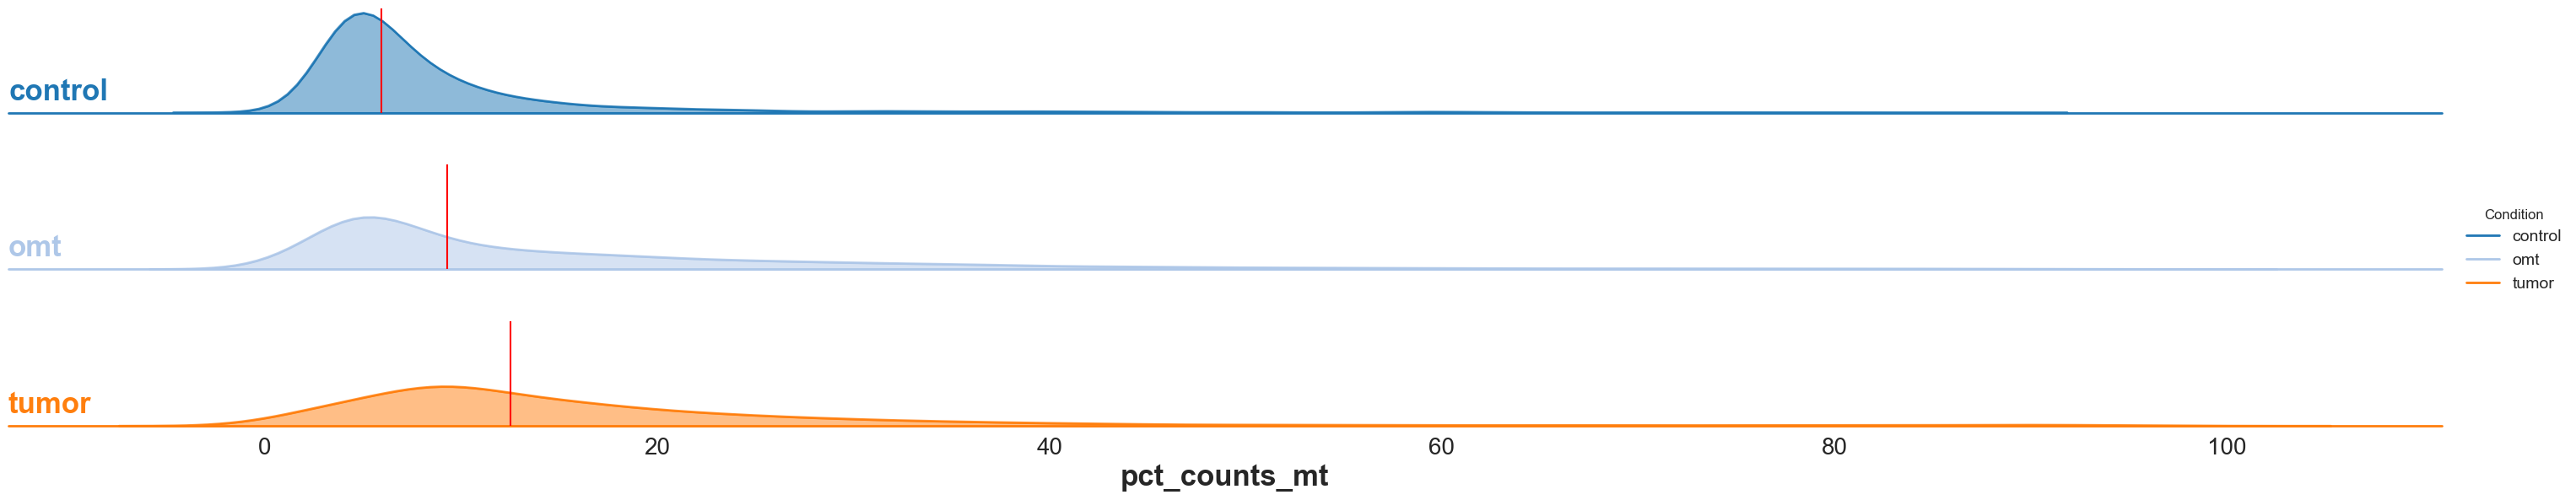

In [ ]:
# # Definir el valor a visualizar (puede ser cualquier columna numérica de adata.obs) print(adata_combined_qc.obs[['Reference', 'Sample', 'Condition']].head())
value = "pct_counts_mt"  # Cambia a la columna que te interese analizar
#value = "n_genes"
#value = 'pct_counts_in_top_20_genes'
#value = "log1p_total_counts" # Nota: log(1+total counts); log1p ayuda a evitar log(0), que no está definido.

df = df.sort_values('Condition') # Ordenar los datos por la columna 'Sample'; alternativamente elegid:['Reference', 'Sample', 'Condition']

# Crear el gráfico FacetGrid para visualizar diferentes muestras en filas
sns.set(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

g = sns.FacetGrid(df, row="Condition", hue="Condition", aspect=15, height=2, palette="tab20")                   # SOLO UNA  CONDICIÓN A ELEGIR ['Reference', 'Sample', 'Condition']
# g = sns.FacetGrid(df, row="Sample", hue="Reference", aspect=15, height=2, palette=["#ADD8E6", "#ff7f0e"]) 

# Azul más claro== palette=["#87CEEB", "#ff7f0e"]  # Azul polvorienta + naranja claro palette=["#B0E0E6", "#FFE4B5"]; Azul cielo + naranja == palette=["#ADD8E6", "#ff7f0e"]  # Azul claro + naranja == palette=["#B0E0E6", "#ff7f0e"]  # Azul polvorienta + naranja;   # Azul cielo + melocotón claro palette=["#87CEEB", "#FFDAB9"]

palette=["#B0E0E6", "#ff7f0e"]  # Azul claro + papaya claro
# Mapea los gráficos KDE para la columna seleccionada
g.map(sns.kdeplot, value, clip_on=False, fill=True, alpha=0.5, linewidth=1.5)
g.map(sns.kdeplot, value, clip_on=False, alpha=0.8, lw=2)

# Agregar líneas horizontales en y=0
g.map(plt.axhline, y=0, lw=2, clip_on=False)

# Función para agregar etiquetas en cada gráfico
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes, fontsize=25) 

# Agregar etiquetas usando la función definida
g.map(label, value)

# Ajustar los márgenes del gráfico
g.figure.subplots_adjust(hspace=0.5)

# Establecer los títulos, ocultar los ticks de y y quitar el borde inferior y izquierdo
g.set_titles("")  
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

# Aumentar tamaño de las etiquetas de los ejes X e Y
g.set_xlabels(value, fontsize=25, fontweight='bold')  

# Calcular la mediana por cada Sample
medians = df.groupby("Condition")[value].median()

# Dibujar la mediana correspondiente en cada subgráfico
for ax, sample in zip(g.axes.flat, medians.index):
    ax.tick_params(axis='x', labelsize=20)  
    ax.tick_params(axis='y', labelsize=14)
    ax.axvline(x=medians[sample], color='red', linestyle='-')

# Añadir una leyenda
g.add_legend(title="Condition", fontsize=14, title_fontsize=16)

# Salvar el gráfico
plt.savefig('C:/Users/pablo/OneDrive/Escritorio/CEU SAN PABLO/4º/TFG/Código/Noncoding/pct_counts_mt_byCondition.pdf')

# Mostrar el gráfico
plt.show()

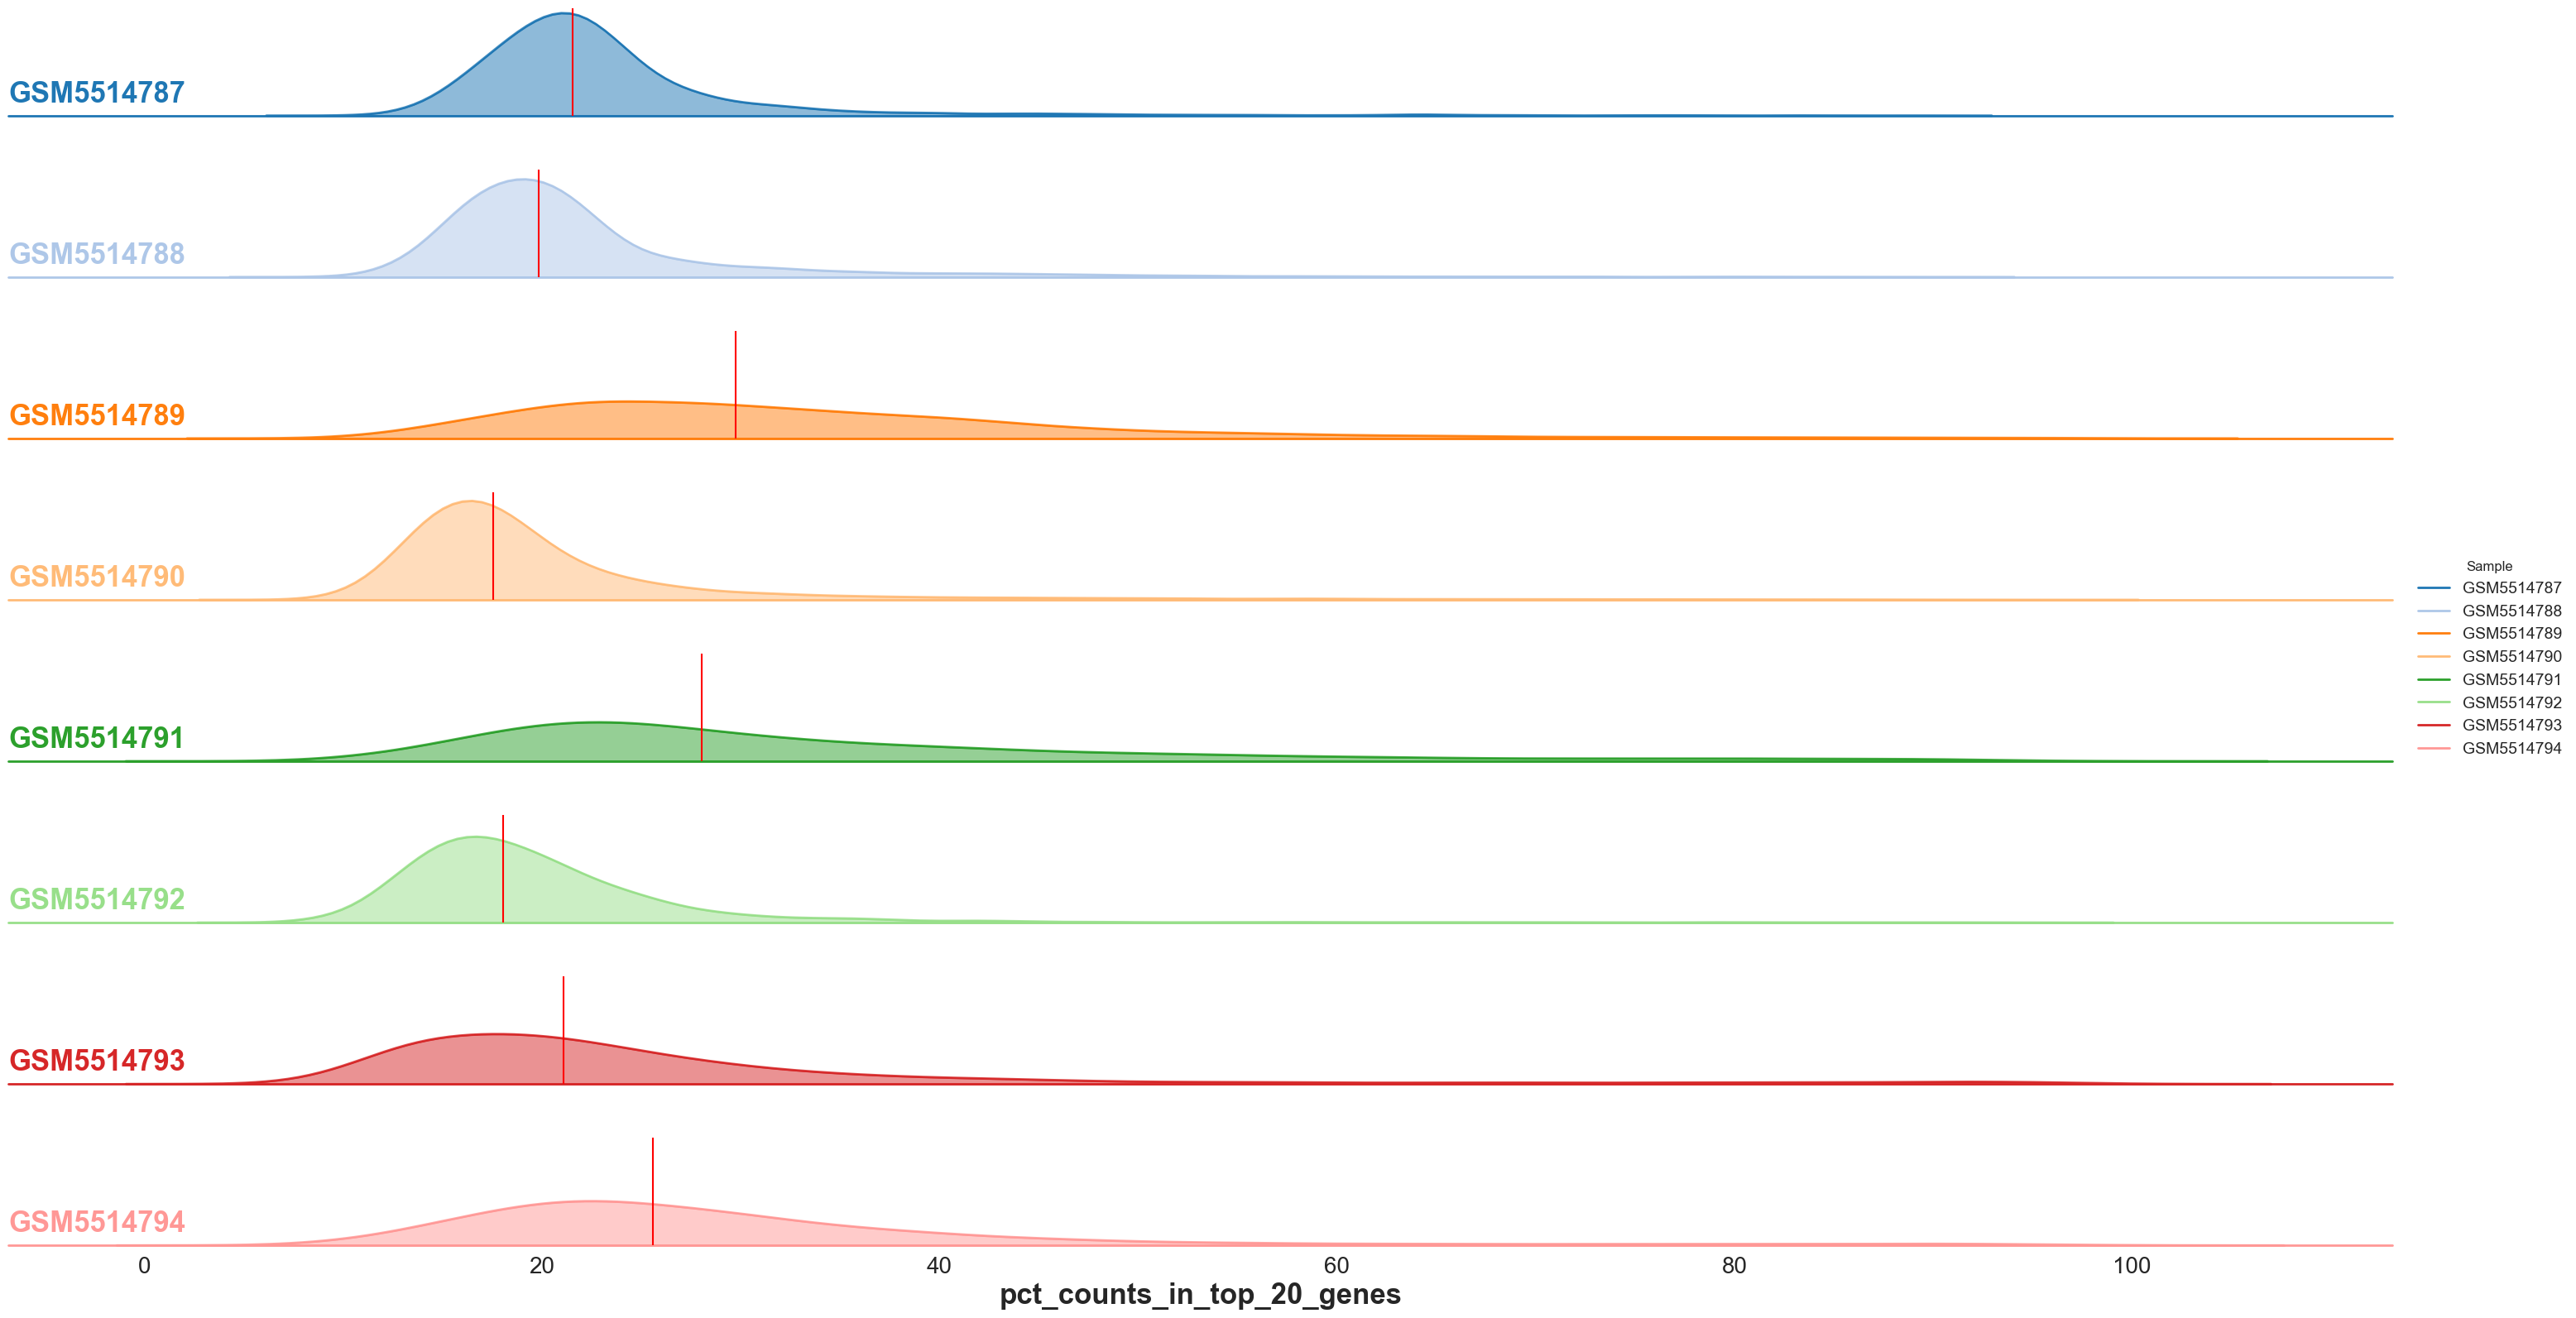

In [ ]:
# # Definir el valor a visualizar (puede ser cualquier columna numérica de adata.obs) print(adata_combined_qc.obs[['Reference', 'Sample', 'Condition']].head())
# value = "pct_counts_mt"  # Cambia a la columna que te interese analizar
# value = "n_genes"
value = 'pct_counts_in_top_20_genes'
#value = "log1p_total_counts" # Nota: log(1+total counts); log1p ayuda a evitar log(0), que no está definido.

df = df.sort_values('Sample') # Ordenar los datos por la columna 'Sample'; alternativamente elegid:['Reference', 'Sample', 'Condition']

# Crear el gráfico FacetGrid para visualizar diferentes muestras en filas
sns.set(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

g = sns.FacetGrid(df, row="Sample", hue="Sample", aspect=15, height=2, palette="tab20")                   # SOLO UNA  CONDICIÓN A ELEGIR ['Reference', 'Sample', 'Condition']
# g = sns.FacetGrid(df, row="Sample", hue="Reference", aspect=15, height=2, palette=["#ADD8E6", "#ff7f0e"]) 

# Azul más claro== palette=["#87CEEB", "#ff7f0e"]  # Azul polvorienta + naranja claro palette=["#B0E0E6", "#FFE4B5"]; Azul cielo + naranja == palette=["#ADD8E6", "#ff7f0e"]  # Azul claro + naranja == palette=["#B0E0E6", "#ff7f0e"]  # Azul polvorienta + naranja;   # Azul cielo + melocotón claro palette=["#87CEEB", "#FFDAB9"]

palette=["#B0E0E6", "#ff7f0e"]  # Azul claro + papaya claro
# Mapea los gráficos KDE para la columna seleccionada
g.map(sns.kdeplot, value, clip_on=False, fill=True, alpha=0.5, linewidth=1.5)
g.map(sns.kdeplot, value, clip_on=False, alpha=0.8, lw=2)

# Agregar líneas horizontales en y=0
g.map(plt.axhline, y=0, lw=2, clip_on=False)

# Función para agregar etiquetas en cada gráfico
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes, fontsize=25) 

# Agregar etiquetas usando la función definida
g.map(label, value)

# Ajustar los márgenes del gráfico
g.figure.subplots_adjust(hspace=0.5)

# Establecer los títulos, ocultar los ticks de y y quitar el borde inferior y izquierdo
g.set_titles("")  
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

# Aumentar tamaño de las etiquetas de los ejes X e Y
g.set_xlabels(value, fontsize=25, fontweight='bold')  

# Calcular la mediana por cada Sample
medians = df.groupby("Sample")[value].median()

# Dibujar la mediana correspondiente en cada subgráfico
for ax, sample in zip(g.axes.flat, medians.index):
    ax.tick_params(axis='x', labelsize=20)  
    ax.tick_params(axis='y', labelsize=14)
    ax.axvline(x=medians[sample], color='red', linestyle='-')

# Añadir una leyenda
# g.add_legend(title="Sample", fontsize=20, title_fontsize=20)
g.add_legend(title="Sample", fontsize=14, title_fontsize=16)

# Salvar el gráfico
plt.savefig('C:/Users/pablo/OneDrive/Escritorio/CEU SAN PABLO/4º/TFG/Código/Noncoding/pct_counts_in_top_20_genes_bySample.pdf')

# Mostrar el gráfico
plt.show()

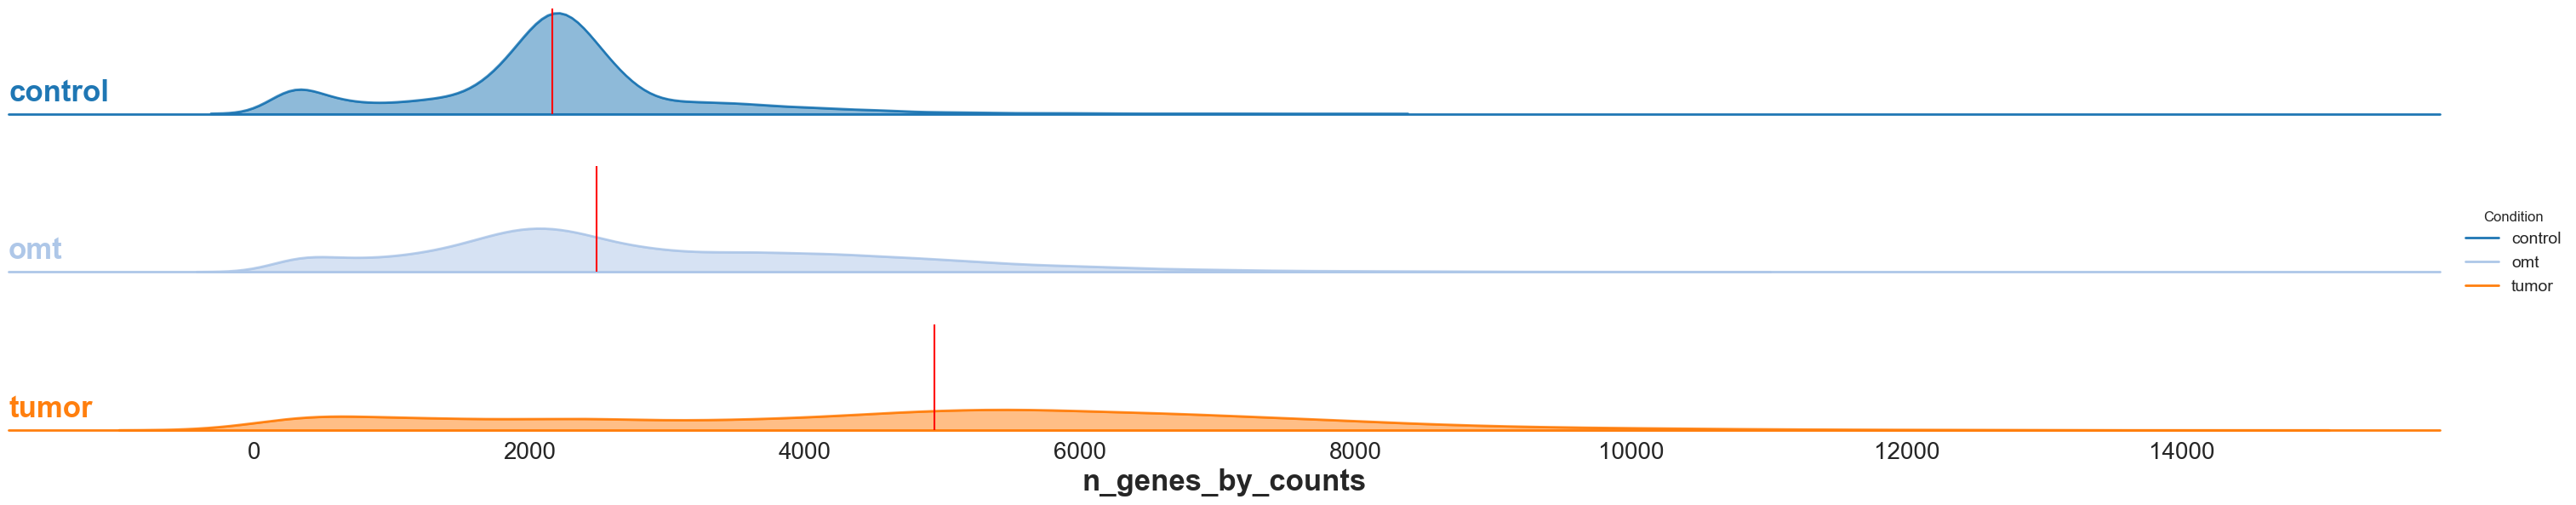

In [ ]:
# # Definir el valor a visualizar (puede ser cualquier columna numérica de adata.obs) print(adata_combined_qc.obs[['Reference', 'Sample', 'Condition']].head())
# value = "pct_counts_mt"  # Cambia a la columna que te interese analizar
value = "n_genes_by_counts"
# value = 'pct_counts_in_top_20_genes'
#value = "log1p_total_counts" # Nota: log(1+total counts); log1p ayuda a evitar log(0), que no está definido.

df = df.sort_values('Condition') # Ordenar los datos por la columna 'Sample'; alternativamente elegid:['Reference', 'Sample', 'Condition']

# Crear el gráfico FacetGrid para visualizar diferentes muestras en filas
sns.set(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

g = sns.FacetGrid(df, row="Condition", hue="Condition", aspect=15, height=2, palette="tab20")                   # SOLO UNA  CONDICIÓN A ELEGIR ['Reference', 'Sample', 'Condition']
# g = sns.FacetGrid(df, row="Sample", hue="Reference", aspect=15, height=2, palette=["#ADD8E6", "#ff7f0e"]) 

# Azul más claro== palette=["#87CEEB", "#ff7f0e"]  # Azul polvorienta + naranja claro palette=["#B0E0E6", "#FFE4B5"]; Azul cielo + naranja == palette=["#ADD8E6", "#ff7f0e"]  # Azul claro + naranja == palette=["#B0E0E6", "#ff7f0e"]  # Azul polvorienta + naranja;   # Azul cielo + melocotón claro palette=["#87CEEB", "#FFDAB9"]

# palette=["#B0E0E6", "#ff7f0e"]  # Azul claro + papaya claro
# Mapea los gráficos KDE para la columna seleccionada
g.map(sns.kdeplot, value, clip_on=False, fill=True, alpha=0.5, linewidth=1.5)
g.map(sns.kdeplot, value, clip_on=False, alpha=0.8, lw=2)

# Agregar líneas horizontales en y=0
g.map(plt.axhline, y=0, lw=2, clip_on=False)

# Función para agregar etiquetas en cada gráfico
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes, fontsize=25) 

# Agregar etiquetas usando la función definida
g.map(label, value)

# Ajustar los márgenes del gráfico
g.figure.subplots_adjust(hspace=0.5)

# Establecer los títulos, ocultar los ticks de y y quitar el borde inferior y izquierdo
g.set_titles("")  
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

# Aumentar tamaño de las etiquetas de los ejes X e Y
g.set_xlabels(value, fontsize=25, fontweight='bold')  

# Calcular la mediana por cada Condition
medians = df.groupby("Condition")[value].median()

# Dibujar la mediana correspondiente en cada subgráfico
for ax, sample in zip(g.axes.flat, medians.index):
    ax.tick_params(axis='x', labelsize=20)  
    ax.tick_params(axis='y', labelsize=14)
    ax.axvline(x=medians[sample], color='red', linestyle='-')

# Añadir una leyenda
# g.add_legend(title="Sample", fontsize=20, title_fontsize=20)
g.add_legend(title="Condition", fontsize=14, title_fontsize=16)

# Salvar el gráfico
plt.savefig('C:/Users/pablo/OneDrive/Escritorio/CEU SAN PABLO/4º/TFG/Código/Noncoding/n_genes_by_counts_byCondition.pdf')

# Mostrar el gráfico
plt.show()

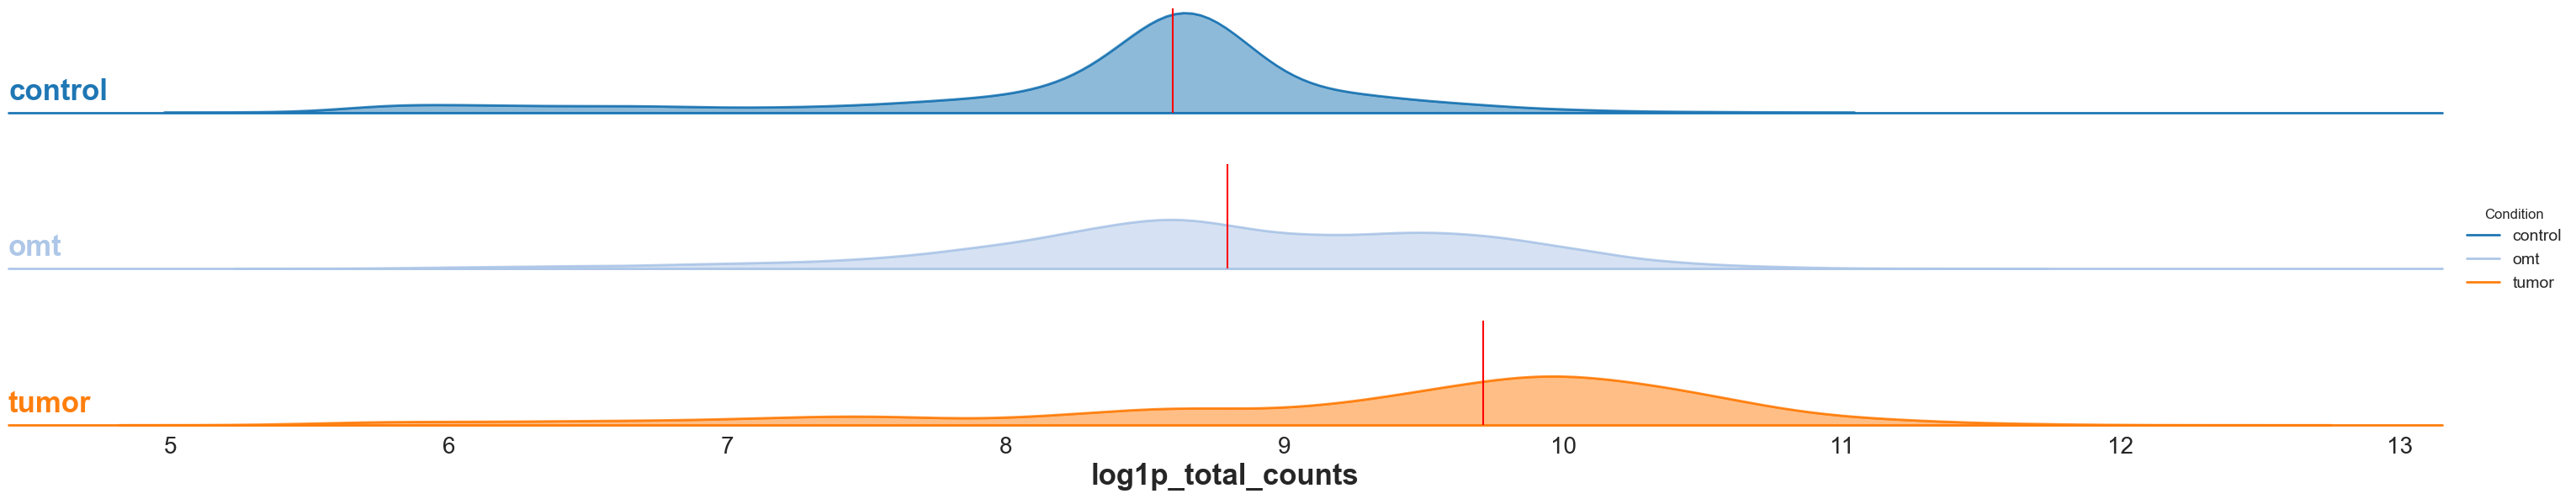

In [ ]:
# # Definir el valor a visualizar (puede ser cualquier columna numérica de adata.obs) print(adata_combined_qc.obs[['Reference', 'Sample', 'Condition']].head())
# value = "pct_counts_mt"  # Cambia a la columna que te interese analizar
# value = "n_genes"
# value = 'pct_counts_in_top_20_genes'
value = "log1p_total_counts" # Nota: log(1+total counts); log1p ayuda a evitar log(0), que no está definido.

df = df.sort_values('Condition') # Ordenar los datos por la columna 'Sample'; alternativamente elegid:['Reference', 'Sample', 'Condition']

# Crear el gráfico FacetGrid para visualizar diferentes muestras en filas
sns.set(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

g = sns.FacetGrid(df, row="Condition", hue="Condition", aspect=15, height=2, palette="tab20")                   # SOLO UNA  CONDICIÓN A ELEGIR ['Reference', 'Sample', 'Condition']
# g = sns.FacetGrid(df, row="Sample", hue="Reference", aspect=15, height=2, palette=["#ADD8E6", "#ff7f0e"]) 

# Azul más claro== palette=["#87CEEB", "#ff7f0e"]  # Azul polvorienta + naranja claro palette=["#B0E0E6", "#FFE4B5"]; Azul cielo + naranja == palette=["#ADD8E6", "#ff7f0e"]  # Azul claro + naranja == palette=["#B0E0E6", "#ff7f0e"]  # Azul polvorienta + naranja;   # Azul cielo + melocotón claro palette=["#87CEEB", "#FFDAB9"]

palette=["#B0E0E6", "#ff7f0e"]  # Azul claro + papaya claro
# Mapea los gráficos KDE para la columna seleccionada
g.map(sns.kdeplot, value, clip_on=False, fill=True, alpha=0.5, linewidth=1.5)
g.map(sns.kdeplot, value, clip_on=False, alpha=0.8, lw=2)

# Agregar líneas horizontales en y=0
g.map(plt.axhline, y=0, lw=2, clip_on=False)

# Función para agregar etiquetas en cada gráfico
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes, fontsize=25) 

# Agregar etiquetas usando la función definida
g.map(label, value)

# Ajustar los márgenes del gráfico
g.figure.subplots_adjust(hspace=0.5)

# Establecer los títulos, ocultar los ticks de y y quitar el borde inferior y izquierdo
g.set_titles("")  
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

# Aumentar tamaño de las etiquetas de los ejes X e Y
g.set_xlabels(value, fontsize=25, fontweight='bold')  

# Calcular la mediana por cada Sample
medians = df.groupby("Condition")[value].median()

# Dibujar la mediana correspondiente en cada subgráfico
for ax, sample in zip(g.axes.flat, medians.index):
    ax.tick_params(axis='x', labelsize=20)  
    ax.tick_params(axis='y', labelsize=14)
    ax.axvline(x=medians[sample], color='red', linestyle='-')

# Añadir una leyenda
# g.add_legend(title="Sample", fontsize=20, title_fontsize=20)
g.add_legend(title="Condition", fontsize=14, title_fontsize=16)

# Salvar el gráfico
plt.savefig('C:/Users/pablo/OneDrive/Escritorio/CEU SAN PABLO/4º/TFG/Código/Noncoding/log1p_total_counts_byCondition.pdf')

# Mostrar el gráfico
plt.show()

# <span style="font-size:32px;color:blue">Preprocessing</span></br><span style="font-size:16px;color:blue">NOT removing outliers and doublets</span> 

<span style="font-size:18px; color:blue">Preprocessing (NOT removing outliers and doublets)</i></span> <span style="font-size:12px; color:blue">**Columns generated** in adata.obs (by cell) y adata.var (by gene).</i></span>
* The outliers will be annotated but not removed

In [26]:
# ✅ USAR ESTA CELDA
# Creación de una función para detectar outliers
def mad_outlier(adata, metric, nmads, upper_only = False):
    M = adata.obs[metric] # Extrae la métrica seleccionada de la tabla de observaciones
    
    if not upper_only:
        return (M < np.median(M) - nmads * mad(M)) | (M > np.median(M) + nmads * mad(M))
    
    return (M > np.median(M) + nmads * mad(M))

In [27]:
# ✅ USAR ESTA CELDA
# Creación de una función para anotar outlier
def pp(adata):
    # Sumando bool ie. False + False = False, True + True = True, False + True = True
    bool_vector = mad_outlier(adata, 'log1p_total_counts', 5) +\
            mad_outlier(adata, 'log1p_n_genes_by_counts', 5) +\
            mad_outlier(adata, 'pct_counts_in_top_20_genes', 5) +\
            mad_outlier(adata, 'pct_counts_mt', 3, upper_only = True)
    
    adata.obs['Outlier'] = bool_vector # Anotar pero no remover !!!!!!!!!!!!!!!!!!!!!!
   
    adata = adata[adata.obs.pct_counts_mt < 25] # Se puede rebajar atendiendo a la naturaleza y caracteristicas del dataset
    
    return adata

* If the number of cells removed in MAD filtering is very large relative to overall cells, it may be worthwhile to increase thresholds or use a less conservative method. ~5-15% is typical.
* Expected doublet rate is typically ~2-10% depending on the number of cells sequenced for 10x workflows

In [28]:
# ✅ USAR ESTA CELDA
adatas_qc_pp_list = [pp(ad) for ad in adatas_qc_list]

In [ ]:
# To check that the object is correct
adatas_qc_pp_list


[View of AnnData object with n_obs × n_vars = 4728 × 32027
     obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'DoubletClass', 'DoubletScore', 'Sample', 'Condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'Outlier'
     var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
     uns: 'filename', 'file_path',
 View of AnnData object with n_obs × n_vars = 8649 × 36929
     obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'DoubletClass', 'DoubletScore', 'Sample', 'Condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_

In [30]:
adatas_qc_pp_list[1].obs.head()

,orig.ident,nCount_RNA,nFeature_RNA,DoubletClass,DoubletScore,Sample,Condition,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,...,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,Outlier
barcode,,,,,,,,,,,,,,,,,,,,,
TCATCCGCACTGGACC-GSM5514788_omt,GSM5514788,90122,8700,singlet,0.009656,GSM5514788,omt,8700,9.071193,90122,...,6517,8.782323,7.231309,15273,9.633907,16.947027,11,2.484907,0.012206,True
AGATGCTGTCAGGCAA-GSM5514788_omt,GSM5514788,84523,8536,singlet,0.014282,GSM5514788,omt,8536,9.052165,84523,...,4314,8.369853,5.103936,16440,9.707533,19.450327,12,2.564949,0.014197,True
GTGCAGCAGAACGTGC-GSM5514788_omt,GSM5514788,63604,9663,singlet,0.315345,GSM5514788,omt,9663,9.176163,63604,...,7780,8.959440,12.231935,6369,8.759355,10.013521,1,0.693147,0.001572,True
TTCGGTCAGGACGGAG-GSM5514788_omt,GSM5514788,61381,10397,singlet,0.030414,GSM5514788,omt,10397,9.249369,61381,...,3562,8.178358,5.803099,8438,9.040619,13.746925,5,1.791759,0.008146,True
TTTACGTCAGCCCAGT-GSM5514788_omt,GSM5514788,52149,7056,singlet,0.011364,GSM5514788,omt,7056,8.861775,52149,...,3193,8.069029,6.122840,7795,8.961366,14.947554,9,2.302585,0.017258,False


In [31]:
# ✅ USAR ESTA CELDA
# Lista con el orden deseado de columnas
column_order = [
    'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Reference', 'Condition',
    'DoubletClass', 'DoubletScore', 'Outlier',
    'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts',
    'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt',
    'pct_counts_ribo', 'pct_counts_hb'
]

# Función que aplica el reordenamiento a un objeto AnnData
def reorder_obs_columns(adata):
    # Filtra columnas que existen en el objeto
    ordered_cols = [col for col in column_order if col in adata.obs.columns]
    # Agrega al final las columnas que no están en el orden deseado
    remaining_cols = [col for col in adata.obs.columns if col not in ordered_cols]
    # Reasigna las columnas en el nuevo orden
    adata.obs = adata.obs[ordered_cols + remaining_cols]
    return adata

# Aplica a cada objeto en la lista adatas_Global
adatas_Global_qc_pp_list = [reorder_obs_columns(ad) for ad in adatas_qc_pp_list]

In [32]:
# ✅ USAR ESTA CELDA
# Concatenar todos los objetos AnnData qc+pp en uno solo. Se reduce los genes y que incorporan el qc y pp realizados en los obj. anndatas.
adata_combined_qc_pp = sc.concat(adatas_Global_qc_pp_list, axis=0, join='outer', fill_value=0)

In [33]:
adata_combined_qc_pp.shape
adata_combined_qc_pp

AnnData object with n_obs × n_vars = 39966 × 48289
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb'

In [ ]:
# To check that the combined object corresponds to the sum of all the anndatas
print(adata_combined_qc_pp.shape)
for i, ad in enumerate(adatas_qc_pp_list):
    print(i, ad.shape)

print("Total células:", sum(ad.n_obs for ad in adatas_qc_pp_list))
print("Total genes unión:", adata_combined_qc_pp.n_vars)
adata_combined_qc_pp.obs.head()

(39966, 48289)
0 (4728, 32027)
1 (8649, 36929)
2 (2971, 38997)
3 (8706, 38250)
4 (4313, 40185)
5 (3531, 41802)
6 (4959, 40744)
7 (2109, 39446)
Total células: 39966
Total genes unión: 48289


,orig.ident,nCount_RNA,nFeature_RNA,Sample,Condition,DoubletClass,DoubletScore,Outlier,n_genes_by_counts,log1p_n_genes_by_counts,...,pct_counts_in_top_20_genes,pct_counts_mt,pct_counts_ribo,pct_counts_hb,total_counts_mt,log1p_total_counts_mt,total_counts_ribo,log1p_total_counts_ribo,total_counts_hb,log1p_total_counts_hb
barcode,,,,,,,,,,,,,,,,,,,,,
CCCTCTCAGCCTATTG-GSM5514787_control,GSM5514787,39408,7200,GSM5514787,control,doublet,0.999920,True,7200,8.881975,...,14.052984,3.542428,18.293240,0.012688,1396,7.242082,7209,8.883224,5,1.791759
ATCGTAGGTAGTGTGG-GSM5514787_control,GSM5514787,39306,6224,GSM5514787,control,singlet,0.000650,True,6224,8.736329,...,19.788327,6.401058,19.248970,0.002544,2516,7.830823,7566,8.931552,1,0.693147
GCAACCGGTGCACATT-GSM5514787_control,GSM5514787,37137,7869,GSM5514787,control,singlet,0.012591,True,7869,8.970813,...,20.661335,12.491585,13.189003,0.005385,4639,8.442470,4898,8.496786,2,1.098612
ATCGTGAGTGGAAATT-GSM5514787_control,GSM5514787,33628,6219,GSM5514787,control,singlet,0.004059,True,6219,8.735525,...,13.459022,2.973712,20.923040,0.008921,1000,6.908755,7036,8.858937,3,1.386294
ATGAGGGAGGATTCCT-GSM5514787_control,GSM5514787,33149,6033,GSM5514787,control,singlet,0.002556,True,6033,8.705165,...,14.998944,3.927720,20.127304,0.015083,1302,7.172425,6672,8.805825,5,1.791759


In [ ]:
# ✅ USAR ESTA CELDA
# Guardar el objeto AnnData combinado en un archivo h5ad que incorporan el qc y pp realizados en los obj. anndatas.
adata_combined_qc_pp.write("Noncoding/adata_combined_qc_pp.h5ad", compression="gzip")

<span style="font-size:18px; color:red">*RECOVERY POINT*</i></span> <span style="font-size:14px; color:salmon">Anndata OBJECT 'adata_combined_Global_qc_pp' qc-analyzed and preprocessed y preprocesado </i></br><span style="font-size:14px; color:salmon"></i></span>

In [38]:
# ✅ USAR ESTA CELDA sólo si se inicia desde aqui
adatas = sc.read('Noncoding/adata_combined_qc_pp.h5ad')

In [39]:
# USAR ESTA CELDA
adatas

AnnData object with n_obs × n_vars = 39966 × 48289
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb'

In [40]:
# ✅ USAR ESTA CELDA
adatas.layers["counts"] = adatas.X.copy() # Guardar las counts raw sin normalizar
# Consultar counts originales	adata.layers['counts']
# Restaurar counts originales	adata.X = adata.layers['counts'].copy()

In [41]:
df2 = adatas.obs.copy()

value = "log1p_total_counts"

df2 = df2.dropna(subset=["Sample", value])

df2[value] = pd.to_numeric(df2[value], errors="coerce")
df2 = df2.dropna(subset=[value])

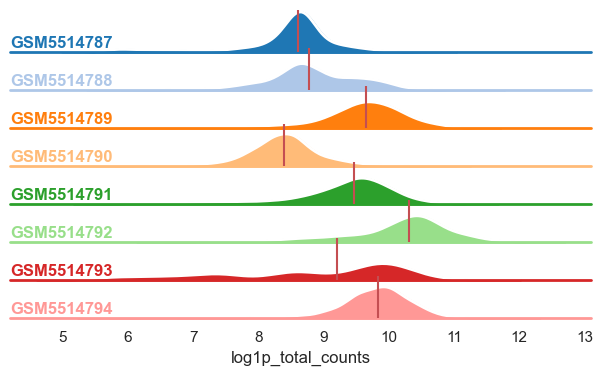

In [ ]:
#value = "pct_counts_mt"
#value = "n_genes"
#value = 'pct_counts_in_top_20_genes'
value = "log1p_total_counts"

sns.set(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

g = sns.FacetGrid(df2, row="Sample", hue="Sample", aspect=15, height=0.5, palette="tab20")
#g = sns.FacetGrid(df2, row="Sample", hue="Sample", aspect=15, height=0.5, palette="tab20")

g.map(sns.kdeplot, value, clip_on=False, fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, value, clip_on=False, color="w", lw=2)

g.map(plt.axhline, y=0, lw=2, clip_on=False)

def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)

g.map(label, value)

g.figure.subplots_adjust(hspace=-0.1)

g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)


# Calcular la mediana por grupo (Condition en este caso)
medians = df2.groupby("Sample")[value].median()

# Dibujar la mediana correspondiente a cada subgráfico
for ax, condition in zip(g.axes.flat, medians.index):
    ax.axvline(x=medians[condition], color='r', linestyle='-')

# Salvar el gráfico
plt.savefig('C:/Users/pablo/OneDrive/Escritorio/CEU SAN PABLO/4º/TFG/Código/Noncoding/log1p_total_counts_after_prepro_bySample.pdf', bbox_inches='tight') # tight para que la figura se ajuste automaticamente a los bordes
plt.show()

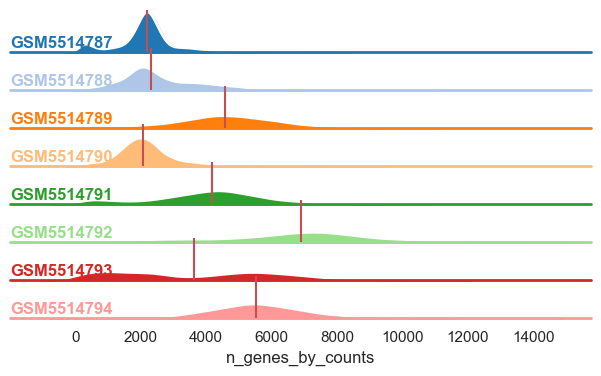

In [ ]:
#value = "pct_counts_mt"
value = "n_genes_by_counts"
#value = 'pct_counts_in_top_20_genes'
# value = "log1p_total_counts"

sns.set(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

g = sns.FacetGrid(df2, row="Sample", hue="Sample", aspect=15, height=0.5, palette="tab20")
#g = sns.FacetGrid(df2, row="Sample", hue="Sample", aspect=15, height=0.5, palette="tab20")

g.map(sns.kdeplot, value, clip_on=False, fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, value, clip_on=False, color="w", lw=2)

g.map(plt.axhline, y=0, lw=2, clip_on=False)

def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)

g.map(label, value)

g.figure.subplots_adjust(hspace=-0.1)

g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)


# Calcular la mediana por grupo (Condition en este caso)
medians = df2.groupby("Sample")[value].median()

# Dibujar la mediana correspondiente a cada subgráfico
for ax, condition in zip(g.axes.flat, medians.index):
    ax.axvline(x=medians[condition], color='r', linestyle='-')

# Salvar el gráfico
plt.savefig('C:/Users/pablo/OneDrive/Escritorio/CEU SAN PABLO/4º/TFG/Código/Noncoding/n_genes_by_counts_after_prepro_bySample.pdf', bbox_inches='tight') # tight para que la figura se ajuste automaticamente a los bordes
plt.show()

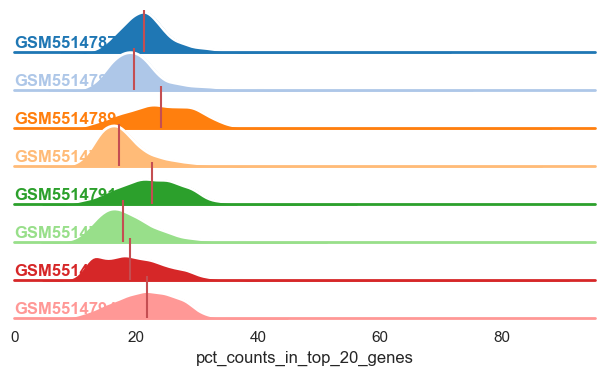

In [ ]:
#value = "pct_counts_mt"
#value = "n_genes"
value = 'pct_counts_in_top_20_genes'
# value = "log1p_total_counts"

sns.set(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

g = sns.FacetGrid(df2, row="Sample", hue="Sample", aspect=15, height=0.5, palette="tab20")
#g = sns.FacetGrid(df2, row="Sample", hue="Sample", aspect=15, height=0.5, palette="tab20")

g.map(sns.kdeplot, value, clip_on=False, fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, value, clip_on=False, color="w", lw=2)

g.map(plt.axhline, y=0, lw=2, clip_on=False)

def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)

g.map(label, value)

g.figure.subplots_adjust(hspace=-0.1)

g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)


# Calcular la mediana por grupo (Condition en este caso)
medians = df2.groupby("Sample")[value].median()

# Dibujar la mediana correspondiente a cada subgráfico
for ax, condition in zip(g.axes.flat, medians.index):
    ax.axvline(x=medians[condition], color='r', linestyle='-')

# Salvar el gráfico
plt.savefig('C:/Users/pablo/OneDrive/Escritorio/CEU SAN PABLO/4º/TFG/Código/Noncoding/pct_counts_in_top_20_genes_after_prepro_bySample.pdf', bbox_inches='tight') # tight para que la figura se ajuste automaticamente a los bordes
plt.show()

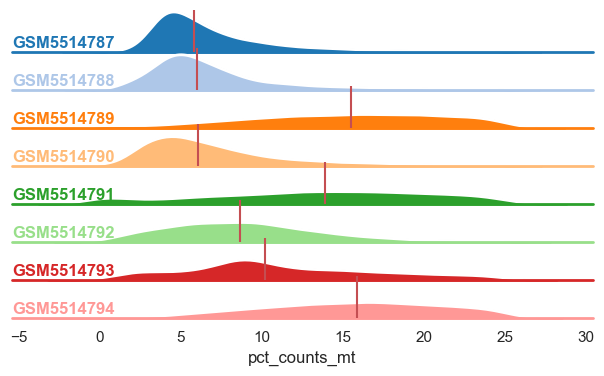

In [ ]:
value = "pct_counts_mt"
#value = "n_genes"
#value = 'pct_counts_in_top_20_genes'
# value = "log1p_total_counts"

sns.set(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

g = sns.FacetGrid(df2, row="Sample", hue="Sample", aspect=15, height=0.5, palette="tab20")
#g = sns.FacetGrid(df2, row="Sample", hue="Sample", aspect=15, height=0.5, palette="tab20")

g.map(sns.kdeplot, value, clip_on=False, fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, value, clip_on=False, color="w", lw=2)

g.map(plt.axhline, y=0, lw=2, clip_on=False)

def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)

g.map(label, value)

g.figure.subplots_adjust(hspace=-0.1)

g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)


# Calcular la mediana por grupo (Condition en este caso)
medians = df2.groupby("Sample")[value].median()

# Dibujar la mediana correspondiente a cada subgráfico
for ax, condition in zip(g.axes.flat, medians.index):
    ax.axvline(x=medians[condition], color='r', linestyle='-')

# Salvar el gráfico
plt.savefig('C:/Users/pablo/OneDrive/Escritorio/CEU SAN PABLO/4º/TFG/Código/Noncoding/pct_counts_mt_after_prepro_bySample.pdf', bbox_inches='tight') # tight para que la figura se ajuste automaticamente a los bordes
plt.show()

<span style="font-size:25px; color:red">*RECOVERY POINT*</i></span>


# <span style="font-size:25px;color:blue">Data preparation. </span>

In [46]:
# ✅ USAR ESTA CELDA
#adata_query_annotated = sc.read('unintegrated.h5ad')
adatas = sc.read('Noncoding/adata_combined_qc_pp.h5ad') 
# Objeto Annadata anotado con scvi y celltypist, preprocesado con doublets y outlier

In [47]:
adatas

AnnData object with n_obs × n_vars = 39966 × 48289
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb'

In [48]:
# ✅ USAR ESTA CELDA
adatas.obs

,orig.ident,nCount_RNA,nFeature_RNA,Sample,Condition,DoubletClass,DoubletScore,Outlier,n_genes_by_counts,log1p_n_genes_by_counts,...,pct_counts_in_top_20_genes,pct_counts_mt,pct_counts_ribo,pct_counts_hb,total_counts_mt,log1p_total_counts_mt,total_counts_ribo,log1p_total_counts_ribo,total_counts_hb,log1p_total_counts_hb
barcode,,,,,,,,,,,,,,,,,,,,,
CCCTCTCAGCCTATTG-GSM5514787_control,GSM5514787,39408,7200,GSM5514787,control,doublet,0.999920,True,7200,8.881975,...,14.052984,3.542428,18.293240,0.012688,1396,7.242082,7209,8.883224,5,1.791759
ATCGTAGGTAGTGTGG-GSM5514787_control,GSM5514787,39306,6224,GSM5514787,control,singlet,0.000650,True,6224,8.736329,...,19.788327,6.401058,19.248970,0.002544,2516,7.830823,7566,8.931552,1,0.693147
GCAACCGGTGCACATT-GSM5514787_control,GSM5514787,37137,7869,GSM5514787,control,singlet,0.012591,True,7869,8.970813,...,20.661335,12.491585,13.189003,0.005385,4639,8.442470,4898,8.496786,2,1.098612
ATCGTGAGTGGAAATT-GSM5514787_control,GSM5514787,33628,6219,GSM5514787,control,singlet,0.004059,True,6219,8.735525,...,13.459022,2.973712,20.923040,0.008921,1000,6.908755,7036,8.858937,3,1.386294
ATGAGGGAGGATTCCT-GSM5514787_control,GSM5514787,33149,6033,GSM5514787,control,singlet,0.002556,True,6033,8.705165,...,14.998944,3.927720,20.127304,0.015083,1302,7.172425,6672,8.805825,5,1.791759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTCTCTCCACGACAGA-GSM5514794_tumor,GSM5514794,681,352,GSM5514794,tumor,singlet,0.000442,True,352,5.866468,...,24.375918,3.230543,36.857562,0.000000,22,3.135494,251,5.529429,0,0.000000
ATGAGTCCAGATACTC-GSM5514794_tumor,GSM5514794,816,320,GSM5514794,tumor,singlet,0.000353,True,320,5.771441,...,35.539216,0.000000,32.107843,0.000000,0,0.000000,262,5.572154,0,0.000000
GGTTCTCCAATCCAGT-GSM5514794_tumor,GSM5514794,523,270,GSM5514794,tumor,singlet,0.000513,True,270,5.602119,...,27.151052,0.000000,38.049713,0.000000,0,0.000000,199,5.298317,0,0.000000


In [49]:
# ✅ USAR ESTA CELDA
adatas.layers["counts"] = adatas.X.copy() # Guardar las counts raw sin normalizar
# Consultar counts originales	adata.layers['counts']
# Restaurar counts originales	adata.X = adata.layers['counts'].copy()

In [50]:
# ✅ USAR ESTA CELDA
adatas_raw = adatas.copy()


In [51]:
# PRUEBAS PARA VER QUE ESTÉ CORRECTO
print(adatas.layers.keys())

KeysView(Layers with keys: counts)


In [52]:
# ✅ USAR ESTA CELDA
adatas_raw.write("Noncoding/adatas_raw.h5ad")

<span style="font-size:25px; color:red">*RECOVERY POINT*</i></span> </br>



In [53]:
adatas_raw=sc.read('Noncoding/adatas_raw.h5ad') 


In [54]:
adatas_raw

AnnData object with n_obs × n_vars = 39966 × 48289
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb'
    layers: 'counts'

In [ ]:
# Test
print(adatas_raw)
print(adatas_raw.X.min(), adatas_raw.X.max())
print(adatas_raw.layers.keys())

AnnData object with n_obs × n_vars = 39966 × 48289
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb'
    layers: 'counts'
0 28349
KeysView(Layers with keys: counts)


In [ ]:
# Test
from scipy import sparse
import numpy as np

def min_max(X):
    if sparse.issparse(X):
        return X.data.min(), X.data.max()
    else:
        return X.min(), X.max()

print("X:", min_max(adatas_raw.X))
print("counts:", min_max(adatas_raw.layers["counts"]))
# print("logcounts:", min_max(adatas_raw.layers["logcounts"]))

X: (1, 28349)
counts: (1, 28349)


In [57]:
adatas_raw.obs

,orig.ident,nCount_RNA,nFeature_RNA,Sample,Condition,DoubletClass,DoubletScore,Outlier,n_genes_by_counts,log1p_n_genes_by_counts,...,pct_counts_in_top_20_genes,pct_counts_mt,pct_counts_ribo,pct_counts_hb,total_counts_mt,log1p_total_counts_mt,total_counts_ribo,log1p_total_counts_ribo,total_counts_hb,log1p_total_counts_hb
barcode,,,,,,,,,,,,,,,,,,,,,
CCCTCTCAGCCTATTG-GSM5514787_control,GSM5514787,39408,7200,GSM5514787,control,doublet,0.999920,True,7200,8.881975,...,14.052984,3.542428,18.293240,0.012688,1396,7.242082,7209,8.883224,5,1.791759
ATCGTAGGTAGTGTGG-GSM5514787_control,GSM5514787,39306,6224,GSM5514787,control,singlet,0.000650,True,6224,8.736329,...,19.788327,6.401058,19.248970,0.002544,2516,7.830823,7566,8.931552,1,0.693147
GCAACCGGTGCACATT-GSM5514787_control,GSM5514787,37137,7869,GSM5514787,control,singlet,0.012591,True,7869,8.970813,...,20.661335,12.491585,13.189003,0.005385,4639,8.442470,4898,8.496786,2,1.098612
ATCGTGAGTGGAAATT-GSM5514787_control,GSM5514787,33628,6219,GSM5514787,control,singlet,0.004059,True,6219,8.735525,...,13.459022,2.973712,20.923040,0.008921,1000,6.908755,7036,8.858937,3,1.386294
ATGAGGGAGGATTCCT-GSM5514787_control,GSM5514787,33149,6033,GSM5514787,control,singlet,0.002556,True,6033,8.705165,...,14.998944,3.927720,20.127304,0.015083,1302,7.172425,6672,8.805825,5,1.791759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTCTCTCCACGACAGA-GSM5514794_tumor,GSM5514794,681,352,GSM5514794,tumor,singlet,0.000442,True,352,5.866468,...,24.375918,3.230543,36.857562,0.000000,22,3.135494,251,5.529429,0,0.000000
ATGAGTCCAGATACTC-GSM5514794_tumor,GSM5514794,816,320,GSM5514794,tumor,singlet,0.000353,True,320,5.771441,...,35.539216,0.000000,32.107843,0.000000,0,0.000000,262,5.572154,0,0.000000
GGTTCTCCAATCCAGT-GSM5514794_tumor,GSM5514794,523,270,GSM5514794,tumor,singlet,0.000513,True,270,5.602119,...,27.151052,0.000000,38.049713,0.000000,0,0.000000,199,5.298317,0,0.000000


# <span style="font-size:25px;color:blue">Initial processing without integration</span> <span style="font-size:1px; color:black">. </span>

## <span style="font-size:20px;color:dodgerblue"> **1.- Without** Batch aware</span> 

In [58]:
batch_key = "Sample"
label_key = 'preannotation' # or ref_celltypist_label
condition_key='Condition' # (control / lesión-tipo)

In [59]:
# Restaurar raw counts en X
adatas_raw.X = adatas_raw.layers["counts"].copy()

# Eliminar marca previa de log1p
if "log1p" in adatas_raw.uns:
    del adatas_raw.uns["log1p"]

In [60]:
adatas_raw

AnnData object with n_obs × n_vars = 39966 × 48289
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb'
    layers: 'counts'

In [61]:
# Normalización y log-transformación (metodos permisivos con genes con conteo = 0) Por eso no filtro
sc.pp.normalize_total(adatas_raw)
sc.pp.log1p(adatas_raw)

# Guardar logcounts
adatas_raw.layers["logcounts"] = adatas_raw.X.copy()

In [62]:
# Asegurarse de que adatas_raw.X es tipo float32
adatas_raw.X = adatas_raw.X.astype('float32')

In [ ]:
# Test
print(adatas_raw)
print(adatas_raw.X.min(), adatas_raw.X.max())
print(adatas_raw.layers.keys())

AnnData object with n_obs × n_vars = 39966 × 48289
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb'
    uns: 'log1p'
    layers: 'counts', 'logcounts'
0.0 8.460823
KeysView(Layers with keys: counts, logcounts)


In [ ]:
# Test
from scipy import sparse
import numpy as np

def min_max(X):
    if sparse.issparse(X):
        return X.data.min(), X.data.max()
    else:
        return X.min(), X.max()

print("X:", min_max(adatas_raw.X))
print("counts:", min_max(adatas_raw.layers["counts"]))
print("logcounts:", min_max(adatas_raw.layers["logcounts"]))

X: (0.034787882, 8.460823)
counts: (1, 28349)
logcounts: (0.034787882, 8.460823)


In [65]:
# Asegurarse de que adatas_raw.X es una matriz dispersa (CSR)
if not isinstance(adatas_raw.X, csr_matrix):
    adatas_raw.X = csr_matrix(adatas_raw.X)

In [66]:
# El metodo scib.preprocessing es más estricto, porque sus métodos posteriores como scale_batch o hvg_batch requieren consistencia.
# sc.pp.filter_cells(adatas_raw, min_genes=200) ya realizado en QC
sc.pp.filter_genes(adatas_raw, min_cells=3)

In [67]:
# Evaluación del ciclo celular
scib.preprocessing.score_cell_cycle(adatas_raw, organism='human')
cell_cycle_genes = scib.preprocessing.get_cell_cycle_genes(organism='human')

In [68]:
adatas_raw

AnnData object with n_obs × n_vars = 39966 × 47611
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase'
    var: 'n_cells'
    uns: 'log1p'
    layers: 'counts', 'logcounts'

### <span style="font-size:20px;color:blue">Prelabel Cells with **CellTypist** Annotation (all the cells) </span>

In [69]:
# ✅ USAR ESTA CELDA
start = time.time()
# --- Prepara la matriz para CellTypist ---
adatas_raw.X = adatas_raw.layers["logcounts"].copy() # Usar 'logcounts' ya es log1p(normalize_total)
adatas_raw.raw = None   # evita conflictos con raw

# --- Cargar el modelo preentrenado ---
ref_model_Tabula_CellTypist = models.Model.load(
    model="Reference_Pablo_celltypist.pkl"
)
# --- Anotación con CellTypist ---
# predictions = [predict_cells(ad.copy()) for ad in adatas_Global] en el caso que quisieramos hacelo por separado.
# Emplear .copy para no usar la forma normalizada de la función 'def predict_cells(adata)' y eliminar el raw counts. 
# Eso lo haremos sobre una copia de anndataobjects almaceadas en adatas

predictions = celltypist.annotate(
    adatas_raw,
    model=ref_model_Tabula_CellTypist,
    majority_voting=False
)
# Nota: majority_voting=True suaviza las predicciones a nivel de cluster. Alternativa si quieres que cuando se ejecute se vea... majority_voting=False, verbose=True)

# --- Guardar las etiquetas en obs ---
adatas_raw.obs["preannotation"] = predictions.predicted_labels
pmat = predictions.probability_matrix  # DataFrame (células × tipos)
adatas_raw.obs["preannotation_score"] = pmat.max(axis=1).values # --- Probabilidad máxima por celda

# --- Restaurar counts en .X para integración posterior
adatas_raw.X = adatas_raw.layers["counts"].copy()
adatas_raw.raw = None

# --- Guardar (sobrescribe el mismo archivo)
adatas_raw.write('Noncoding/adatas_raw.h5ad', compression="gzip")

end = time.time()
print(f"Unintegrated annotation took {end - start:.2f} seconds.")

Unintegrated annotation took 183.09 seconds.


In [70]:
adatas_raw

AnnData object with n_obs × n_vars = 39966 × 47611
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells'
    uns: 'log1p'
    layers: 'counts', 'logcounts'

<span style="font-size:25px; color:red">*RECOVERY POINT*</i></span> </br>


In [5]:
adatas_raw=sc.read('Noncoding/adatas_raw.h5ad') 

In [6]:
adatas_raw

AnnData object with n_obs × n_vars = 39966 × 47611
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells'
    uns: 'log1p'
    layers: 'counts', 'logcounts'

In [7]:
adatas_raw.obs

,orig.ident,nCount_RNA,nFeature_RNA,Sample,Condition,DoubletClass,DoubletScore,Outlier,n_genes_by_counts,log1p_n_genes_by_counts,...,log1p_total_counts_mt,total_counts_ribo,log1p_total_counts_ribo,total_counts_hb,log1p_total_counts_hb,S_score,G2M_score,phase,preannotation,preannotation_score
barcode,,,,,,,,,,,,,,,,,,,,,
CCCTCTCAGCCTATTG-GSM5514787_control,GSM5514787,39408,7200,GSM5514787,control,doublet,0.999920,True,7200,8.881975,...,7.242082,7209,8.883224,5,1.791759,-0.074789,-0.065793,G1,CD8Tex,1.000000
ATCGTAGGTAGTGTGG-GSM5514787_control,GSM5514787,39306,6224,GSM5514787,control,singlet,0.000650,True,6224,8.736329,...,7.830823,7566,8.931552,1,0.693147,-0.022780,0.659517,G2M,Tprolif,1.000000
GCAACCGGTGCACATT-GSM5514787_control,GSM5514787,37137,7869,GSM5514787,control,singlet,0.012591,True,7869,8.970813,...,8.442470,4898,8.496786,2,1.098612,-0.102119,-0.125939,G1,Epithelial,1.000000
ATCGTGAGTGGAAATT-GSM5514787_control,GSM5514787,33628,6219,GSM5514787,control,singlet,0.004059,True,6219,8.735525,...,6.908755,7036,8.858937,3,1.386294,0.500251,0.329794,S,Tprolif,1.000000
ATGAGGGAGGATTCCT-GSM5514787_control,GSM5514787,33149,6033,GSM5514787,control,singlet,0.002556,True,6033,8.705165,...,7.172425,6672,8.805825,5,1.791759,0.343723,0.512230,G2M,Tprolif,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTCTCTCCACGACAGA-GSM5514794_tumor,GSM5514794,681,352,GSM5514794,tumor,singlet,0.000442,True,352,5.866468,...,3.135494,251,5.529429,0,0.000000,0.116797,0.037875,S,Plasma,0.995953
ATGAGTCCAGATACTC-GSM5514794_tumor,GSM5514794,816,320,GSM5514794,tumor,singlet,0.000353,True,320,5.771441,...,0.000000,262,5.572154,0,0.000000,-0.030131,0.001954,G2M,Epithelial,0.999982
GGTTCTCCAATCCAGT-GSM5514794_tumor,GSM5514794,523,270,GSM5514794,tumor,singlet,0.000513,True,270,5.602119,...,0.000000,199,5.298317,0,0.000000,-0.045176,-0.028738,G1,Epithelial,1.000000


In [ ]:
# To clean the data from previous attempts
cols_to_drop = [
    "celltypist",
    "celltypist_score"]

adatas_raw.obs.drop(
    columns=[col for col in cols_to_drop if col in adatas_raw.obs.columns],
    inplace=True
)

In [9]:
adatas_raw

AnnData object with n_obs × n_vars = 39966 × 47611
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells'
    uns: 'log1p'
    layers: 'counts', 'logcounts'

In [10]:
adatas_raw.obs

,orig.ident,nCount_RNA,nFeature_RNA,Sample,Condition,DoubletClass,DoubletScore,Outlier,n_genes_by_counts,log1p_n_genes_by_counts,...,log1p_total_counts_mt,total_counts_ribo,log1p_total_counts_ribo,total_counts_hb,log1p_total_counts_hb,S_score,G2M_score,phase,preannotation,preannotation_score
barcode,,,,,,,,,,,,,,,,,,,,,
CCCTCTCAGCCTATTG-GSM5514787_control,GSM5514787,39408,7200,GSM5514787,control,doublet,0.999920,True,7200,8.881975,...,7.242082,7209,8.883224,5,1.791759,-0.074789,-0.065793,G1,CD8Tex,1.000000
ATCGTAGGTAGTGTGG-GSM5514787_control,GSM5514787,39306,6224,GSM5514787,control,singlet,0.000650,True,6224,8.736329,...,7.830823,7566,8.931552,1,0.693147,-0.022780,0.659517,G2M,Tprolif,1.000000
GCAACCGGTGCACATT-GSM5514787_control,GSM5514787,37137,7869,GSM5514787,control,singlet,0.012591,True,7869,8.970813,...,8.442470,4898,8.496786,2,1.098612,-0.102119,-0.125939,G1,Epithelial,1.000000
ATCGTGAGTGGAAATT-GSM5514787_control,GSM5514787,33628,6219,GSM5514787,control,singlet,0.004059,True,6219,8.735525,...,6.908755,7036,8.858937,3,1.386294,0.500251,0.329794,S,Tprolif,1.000000
ATGAGGGAGGATTCCT-GSM5514787_control,GSM5514787,33149,6033,GSM5514787,control,singlet,0.002556,True,6033,8.705165,...,7.172425,6672,8.805825,5,1.791759,0.343723,0.512230,G2M,Tprolif,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTCTCTCCACGACAGA-GSM5514794_tumor,GSM5514794,681,352,GSM5514794,tumor,singlet,0.000442,True,352,5.866468,...,3.135494,251,5.529429,0,0.000000,0.116797,0.037875,S,Plasma,0.995953
ATGAGTCCAGATACTC-GSM5514794_tumor,GSM5514794,816,320,GSM5514794,tumor,singlet,0.000353,True,320,5.771441,...,0.000000,262,5.572154,0,0.000000,-0.030131,0.001954,G2M,Epithelial,0.999982
GGTTCTCCAATCCAGT-GSM5514794_tumor,GSM5514794,523,270,GSM5514794,tumor,singlet,0.000513,True,270,5.602119,...,0.000000,199,5.298317,0,0.000000,-0.045176,-0.028738,G1,Epithelial,1.000000


In [ ]:
# Test

import numpy as np
import scipy.sparse as sp
adatas_raw.X=adatas_raw.layers["logcounts"].copy()

X = adatas_raw.X

if sp.issparse(X):
    data = X.data
else:
    data = X

print("NaN:", np.isnan(data).sum())
print("Inf:", np.isinf(data).sum())
print("Min:", np.nanmin(data))
print("Max:", np.nanmax(data))

NaN: 0
Inf: 0
Min: 0.034787882
Max: 8.460823


In [ ]:
# Test

adatas_raw_prueba = adatas_raw.copy()

# Asegurar categoría
adatas_raw_prueba.obs["Sample"] = adatas_raw_prueba.obs["Sample"].astype("category")

# Filtrar genes sin expresión
sc.pp.filter_genes(adatas_raw_prueba, min_counts=1)

# Opcional: filtrar células vacías
sc.pp.filter_cells(adatas_raw_prueba, min_counts=1)

# Comprobar
print(adatas_raw_prueba)
print(adatas_raw_prueba.obs["Sample"].value_counts())

AnnData object with n_obs × n_vars = 39966 × 46660
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score', 'n_counts'
    var: 'n_cells', 'n_counts'
    uns: 'log1p'
    layers: 'counts', 'logcounts'
Sample
GSM5514790    8706
GSM5514788    8649
GSM5514793    4959
GSM5514787    4728
GSM5514791    4313
GSM5514792    3531
GSM5514789    2971
GSM5514794    2109
Name: count, dtype: int64


In [13]:
# Selección de HVGs batch-aware 
# adatas_raw.X=adatas_raw.layers["logcounts"].copy()
start=time.time()

adata_hvg = adatas_raw.copy()
adata_hvg.X = adata_hvg.layers["logcounts"].copy()
adata_hvg.obs["Sample"] = adata_hvg.obs["Sample"].astype("category")

hvg= scib.preprocessing.hvg_batch(adata_hvg, batch_key="Sample", target_genes=2000, flavor='seurat', n_bins=20, adataOut=False); 
# Si quieres ver los genes que interseccionan en cada batchs elimina el ';' del final de la linea
# VER NOTA abajo ...."adataOut=False/True"
adatas_raw.var["highly_variable"] = adatas_raw.var_names.isin(hvg)

end=time.time()

print(f"Time: {end - start:2f} s")

# ALTERNATIVA HVGs sin batch-aware (solo para visualizar sin integrar)
# sc.pp.highly_variable_genes(adatas_raw, n_top_genes=2000, batch_key=None, flavor="seurat") # Sin batch aware =>batch_key=None, 
# adatas_raw.var

Using 15 HVGs from full intersect set
Using 44 HVGs from n_batch-1 set
Using 103 HVGs from n_batch-2 set
Using 191 HVGs from n_batch-3 set
Using 361 HVGs from n_batch-4 set
Using 693 HVGs from n_batch-5 set
Using 593 HVGs from n_batch-6 set
Using 2000 HVGs
Time: 47.969877 s


In [14]:
adatas_raw

AnnData object with n_obs × n_vars = 39966 × 47611
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells', 'highly_variable'
    uns: 'log1p'
    layers: 'counts', 'logcounts'

In [ ]:
# Test
print(type(hvg))
print(len(hvg))
print(adatas_raw.var["highly_variable"].sum())
adatas_raw

<class 'list'>
2000
2000


AnnData object with n_obs × n_vars = 39966 × 47611
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells', 'highly_variable'
    uns: 'log1p'
    layers: 'counts', 'logcounts'

In [16]:
adatas_raw

AnnData object with n_obs × n_vars = 39966 × 47611
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells', 'highly_variable'
    uns: 'log1p'
    layers: 'counts', 'logcounts'

In [17]:
adatas_raw.var["highly_variable"]

5S-rRNA-ENSG00000277411.1    False
5S-rRNA-ENSG00000285626.1    False
A1BG                         False
A1BG-AS1                     False
A1CF                         False
                             ...  
ZYG11A                       False
ZYG11B                       False
ZYX                          False
ZZEF1                        False
ZZZ3                         False
Name: highly_variable, Length: 47611, dtype: bool

In [ ]:
adatas_raw.write("Noncoding/adatas_raw.h5ad", compression="gzip") # Señalados los HVG



In [ ]:
adatas_raw_hvg = adatas_raw[:, adatas_raw.var["highly_variable"]].copy() 


In [20]:
adatas_raw_hvg

AnnData object with n_obs × n_vars = 39966 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells', 'highly_variable'
    uns: 'log1p'
    layers: 'counts', 'logcounts'

In [21]:
# PCA baseline no integrado
sc.pp.scale(adatas_raw_hvg)
sc.tl.pca(adatas_raw_hvg, use_highly_variable=True )

In [22]:
adatas_raw_hvg

AnnData object with n_obs × n_vars = 39966 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells', 'highly_variable', 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts', 'logcounts'

In [ ]:
adatas_raw_hvg.write("Noncoding/adatas_raw_hvg.h5ad", compression="gzip") # Señalados los HVG



<span style="font-size:25px; color:red">*RECOVERY POINT*</i></span> 

In [24]:
batch_key = "Sample"
condition_key='Condition' # (control / lesión-tipo)
label_key = 'preannotation' # provisional label para el analisis de parámetros biologicos en integración

In [25]:
adatas_raw_hvg=sc.read('Noncoding/adatas_raw_hvg.h5ad') 

In [26]:
adatas_raw_hvg

AnnData object with n_obs × n_vars = 39966 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells', 'highly_variable', 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts', 'logcounts'

#### <span style="font-size:20px;color:blue"> Prepare the object to compare integration methods</span></br> <span style="font-size:18px;color:deepskyblue">The embedding spaces of the methods will be addded in the adatas_bm object. </span>

In [ ]:
adatas_bm = adatas_raw_hvg.copy()
adatas_bm.obsm["Unintegrated"] = adatas_raw_hvg.obsm["X_pca"]

# Salvar original adatas no integrado, preanotado y con solo HVGs para comparación.
adatas_bm.write("Noncoding/adatas_bm.h5ad", compression="gzip")


<h4 style="color:dodgerblue;">Visualization</h4>

In [ ]:
# PCA, vecinos, UMAP
sc.tl.pca(adatas_raw_hvg)

sc.pp.neighbors(adatas_raw_hvg, n_pcs=50)
sc.tl.umap(adatas_raw_hvg)

In [34]:

adatas_raw_hvg

AnnData object with n_obs × n_vars = 39966 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells', 'highly_variable', 'mean', 'std'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'Sample_colors', 'Condition_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'logcounts'
    obsp: 'distances', 'connectivities'

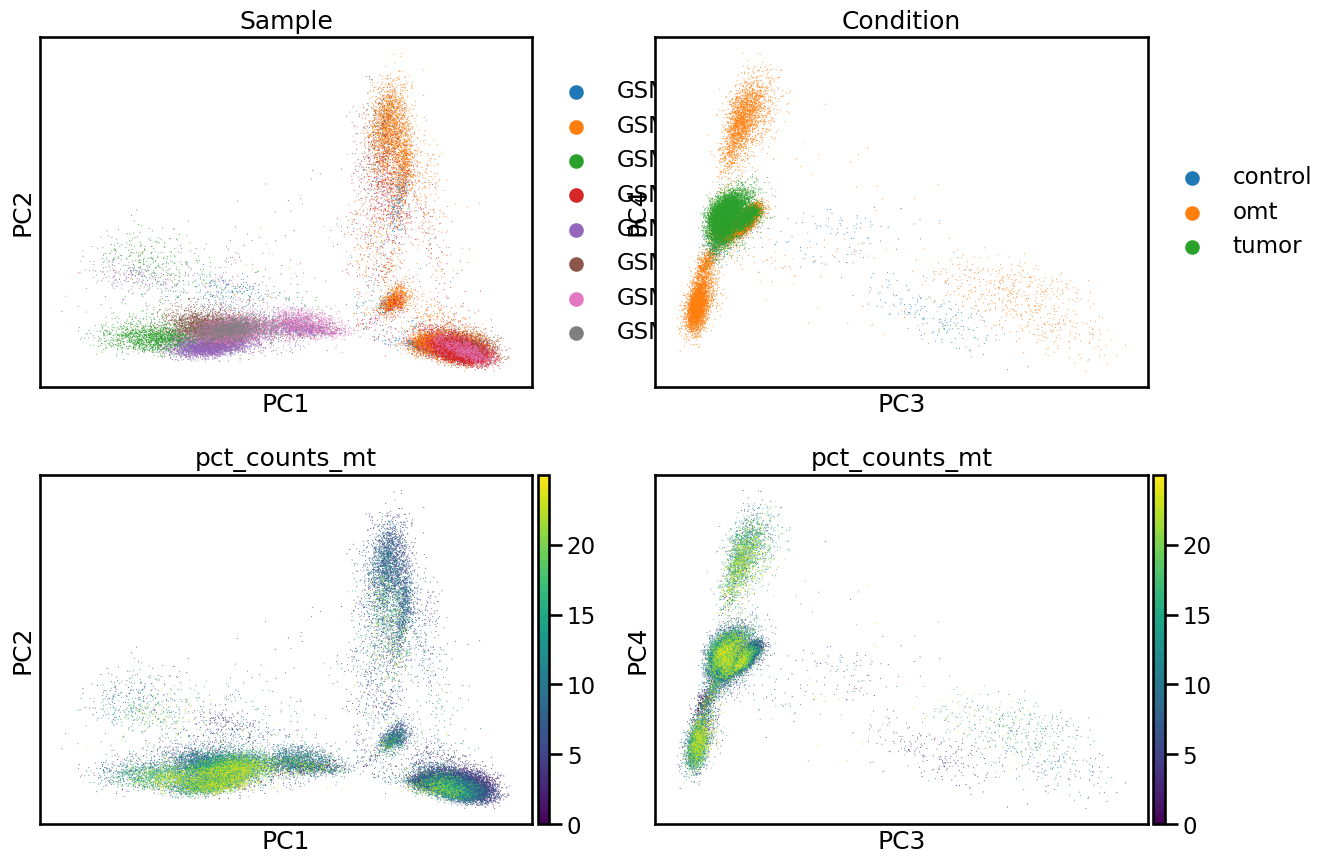

In [35]:
sc.pl.pca(
    adatas_raw_hvg,
    color=["Sample", "Condition", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
)

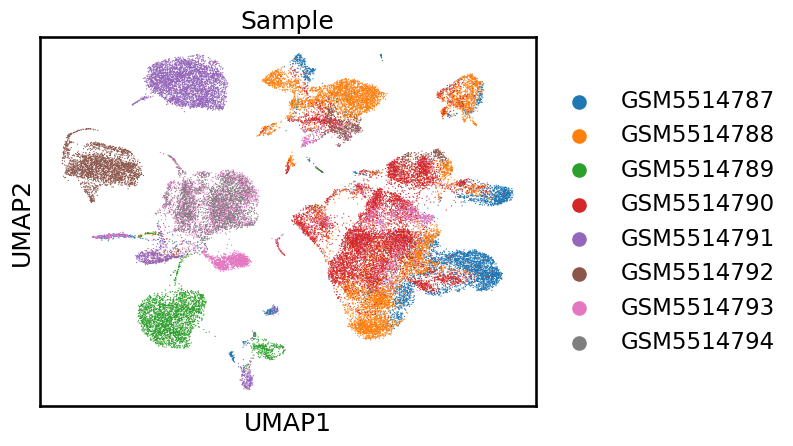

In [36]:
sc.pl.umap(
    adatas_raw_hvg,
    color=["Sample"]
)

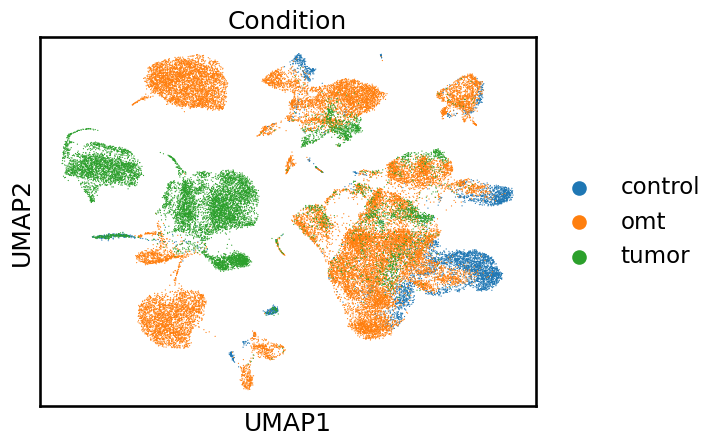

In [37]:
sc.pl.umap(
    adatas_raw_hvg,
    color=["Condition"]
)

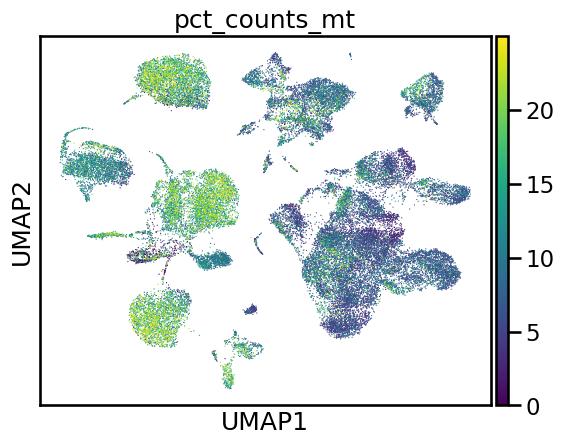

In [38]:
sc.pl.umap(
    adatas_raw_hvg,
    color=["pct_counts_mt"]
)

In [ ]:
# Untintegrated
adatas_raw_hvg.write("Noncoding/adatas_raw_wo_batch_aware.h5ad")


<span style="font-size:25px; color:red">*RECOVERY POINT*</i></span> 

In [40]:
batch_key = "Sample"
condition_key='Condition' # (control / lesión-tipo)
label_key = 'preannotation' # provisional label para el analisis de parámetros biologicos en integración

In [ ]:
adatas_raw_hvg=sc.read("Noncoding/adatas_raw_wo_batch_aware.h5ad")


In [ ]:
# Test
prueba=sc.read("Noncoding/adatas_raw_hvg.h5ad")

In [ ]:
# Test
prueba

AnnData object with n_obs × n_vars = 43570 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells', 'highly_variable', 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts', 'logcounts'

In [43]:
adatas_raw_hvg

AnnData object with n_obs × n_vars = 39966 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells', 'highly_variable', 'mean', 'std'
    uns: 'Condition_colors', 'Sample_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'logcounts'
    obsp: 'connectivities', 'distances'

<h5 style="color:dodgerblue;">Show palettes</h4>

In [44]:
adatas_unintegrated_hvg = adatas_raw_hvg.copy()

In [45]:
adatas_unintegrated_hvg

AnnData object with n_obs × n_vars = 39966 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells', 'highly_variable', 'mean', 'std'
    uns: 'Condition_colors', 'Sample_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'logcounts'
    obsp: 'connectivities', 'distances'

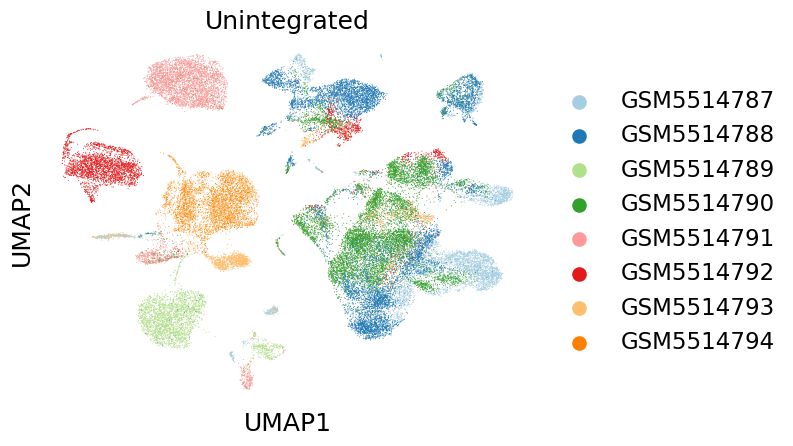

In [46]:
# ✅ USAR ESTA CELDA
unique_batches = adatas_unintegrated_hvg.obs[batch_key].nunique()
palette_viva = sns.color_palette("Paired", unique_batches)  # "tab20", "Set2", "husl", etc.

fig, ax = plt.subplots()

np.random.seed(1)
ri = np.random.permutation(list(range(adatas_unintegrated_hvg.shape[0])))

# Visualización UMAP unintegrated
sc.pl.umap(adatas_unintegrated_hvg[ri,:], color=[batch_key], vmin = .5, size = 2, ax=ax, palette=palette_viva, show=False)
plt.title('Unintegrated')
for spine in ax.spines.values():
    spine.set_visible(False)  # Elimina bordes
plt.savefig('Noncoding/Unintegrated.pdf')
plt.show()

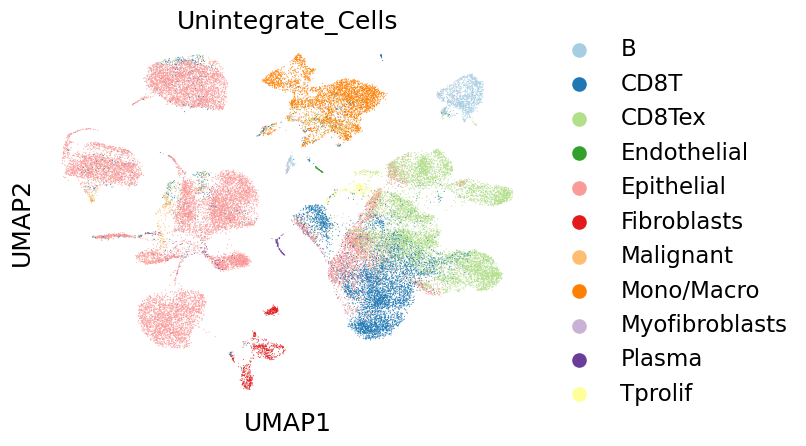

In [ ]:
cell_col = "preannotation"  # o usa label_key si ya lo definiste

# asegurar categórico y paleta
labels = adatas_unintegrated_hvg.obs[cell_col].astype("category")
adatas_unintegrated_hvg.obs[cell_col] = labels
n = len(labels.cat.categories)
palette = sns.color_palette("Paired", min(n, 12)) if n <= 12 else sns.color_palette("husl", n)


# dibujar
np.random.seed(1)
ri = np.random.permutation(adatas_unintegrated_hvg.n_obs)

fig, ax = plt.subplots()
sc.pl.umap(
    adatas_unintegrated_hvg[ri, :],
    color=cell_col,
    size=2,
    palette=palette,
    ax=ax,
    show=False,
)
ax.set_title("Unintegrate_Cells")
for s in ax.spines.values(): s.set_visible(False)
plt.savefig("Noncoding/Unintegrated_celltypist.pdf", bbox_inches="tight")
plt.show()
task_done_beep()

## <span style="color: blue; fontsize:20px"> Selection of the best Leiden resolution</span>

<span style="color: red; fontsize:20px"> RECOVERY POINT ONLY FOR LEIDEN </span>

In [ ]:
adatas_raw_hvg=sc.read("Noncoding/adatas_raw_wo_batch_aware.h5ad")

In [49]:
adatas_raw_hvg

AnnData object with n_obs × n_vars = 39966 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells', 'highly_variable', 'mean', 'std'
    uns: 'Condition_colors', 'Sample_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'logcounts'
    obsp: 'connectivities', 'distances'

In [50]:
# ✅ USAR ESTA CELDA
# Reducción de datos (PCA, UMAP, etc.)
scib.preprocessing.reduce_data(adatas_raw_hvg, flavor='seurat', batch_key="Sample", pca=True, pca_comps=50, overwrite_hvg=False, neighbors=True, use_rep='X_pca', umap=True)

task_done_beep()

PCA
Nearest Neigbours
UMAP


In [51]:
adatas_hvg=adatas_raw_hvg.copy()

In [52]:
adatas_hvg.write("Noncoding/adatas_for_leiden_hvg.h5ad", compression="gzip")

<span style="color: red; fontsize:20px"> PUNTO DE RECUPERACIÓN </span>

In [53]:
adatas_hvg = sc.read("Noncoding/adatas_for_leiden_hvg.h5ad") 
input_h5ad_path = adatas_hvg     # p.ej. 'adatas_hvg_postreduce.h5ad' o deja None si ya tienes `adatas_hvg` en memoria
batch_key = 'Sample'

# Estabilidad
stab_resolutions = [0.2, 0.5, 0.8, 1.0, 1.2, 1.5]
n_repeats = 8
keep_prob = 0.9
use_subset = True
max_cells = 120_000
random_seed = 0
neighbors_key = None       # p.ej. 'scvi' si usas ese grafo; None usa el default

# Salidas 
stability_csv = 'C:/Users/pablo/OneDrive/Escritorio/CEU SAN PABLO/4º/TFG/Código/Output_Leiden_Noncoding/leiden_stability_summary.csv'
stability_pdf = 'C:/Users/pablo/OneDrive/Escritorio/CEU SAN PABLO/4º/TFG/Código/Output_Leiden_Noncoding/leiden_stability_curve.pdf'
clustree_png  = 'C:/Users/pablo/OneDrive/Escritorio/CEU SAN PABLO/4º/TFG/Código/Output_Leiden_Noncoding/clustree_leiden_style_custom.png'
metrics_csv   = 'C:/Users/pablo/OneDrive/Escritorio/CEU SAN PABLO/4º/TFG/Código/Output_Leiden_Noncoding/leiden_resolution_summary_clean.csv'
metrics_pdf   = 'C:/Users/pablo/OneDrive/Escritorio/CEU SAN PABLO/4º/TFG/Código/Output_Leiden_Noncoding/leiden_resolution_metrics_ext.pdf'
save_h5ad     = 'C:/Users/pablo/OneDrive/Escritorio/CEU SAN PABLO/4º/TFG/Código/Output_Leiden_Noncoding/adatas_uninteg_hvg_best.h5ad'

# Opciones de clustree-like
min_flow_prop = 0.05       # filtra aristas <5% del flujo del nodo origen
top_k_per_node = 2         # como máximo 2 aristas salientes por nodo
label_mode = 'id_sizepct'  # 2ª línea: porcentaje del total en el nodo; ('id_inprop' | 'id_size' | 'id_sizepct')
node_palette_mode = 'tab10' # 'tab10' o lista HEX personalizada
edge_cmap = 'plasma'       # colormap para aristas: 'viridis','plasma','magma','cividis', etc.

task_done_beep()

In [54]:
# =====================================================
# ✅ FUNCIONES (compactas y con logs breves)
# =====================================================
import time, numpy as np, pandas as pd, scanpy as sc, matplotlib.pyplot as plt, matplotlib as mpl, networkx as nx
from matplotlib.lines import Line2D
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score, adjusted_mutual_info_score, normalized_mutual_info_score
from scipy.sparse import coo_matrix
from tqdm.auto import tqdm

def ensure_neighbors(adata, neighbors_key=None, use_rep='X_pca', n_pcs=None):
    conn_key = f"{neighbors_key}_connectivities" if neighbors_key else 'connectivities'
    if conn_key not in adata.obsp:
        if use_rep not in adata.obsm and use_rep == 'X_pca':
            sc.tl.pca(adata, svd_solver='arpack', n_comps=(n_pcs or 50))
        sc.pp.neighbors(adata, use_rep=use_rep, n_pcs=n_pcs)
    return conn_key

def perturb_connectivities(conn, keep_prob=0.9, random_state=0):
    rng = np.random.default_rng(random_state)
    A = conn.tocoo(copy=True)
    m = rng.random(A.data.shape[0]) < keep_prob
    A_pert = coo_matrix((A.data[m], (A.row[m], A.col[m])), shape=A.shape)
    return A_pert.maximum(A_pert.T).tocsr()

def _entropy(labels):
    s = pd.Series(labels); p = s.value_counts(normalize=True)
    return -(p * np.log(p + 1e-12)).sum()

def _mutual_info(y1, y2):
    ct = pd.crosstab(pd.Series(y1), pd.Series(y2))
    P = ct.values.astype(float); P /= P.sum()
    pi = P.sum(axis=1, keepdims=True); pj = P.sum(axis=0, keepdims=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        Q = np.where(P > 0, P * np.log(P / (pi @ pj)), 0.0)
    return Q.sum()

def variation_of_information(y1, y2):
    return _entropy(y1) + _entropy(y2) - 2 * _mutual_info(y1, y2)

def run_stability_suite(adata, resolutions, n_repeats=8, keep_prob=0.9, base_key='leiden_stab',
                        random_seed=0, use_subset=False, max_cells=120_000,
                        neighbors_key=None, verbose=True, save_csv_path='leiden_stability_summary.csv'):
    t0 = time.time()
    conn_key = ensure_neighbors(adata, neighbors_key=neighbors_key)
    if use_subset and adata.n_obs > max_cells:
        rng = np.random.default_rng(random_seed)
        idx = np.sort(rng.choice(adata.n_obs, size=max_cells, replace=False))
        ad = adata[idx].copy()
    else:
        ad, idx = adata, None
    base_conn = ad.obsp[conn_key]
    if verbose:
        print(f"[stability] n_obs={ad.n_obs} | res={list(resolutions)} | reps={n_repeats} | keep={keep_prob}")
    assignments = {r: [] for r in resolutions}
    for r in tqdm(resolutions, desc='Resoluciones', unit='res'):
        for rep in range(n_repeats):
            seed = random_seed + 1000*rep + int(r*100)
            adj = perturb_connectivities(base_conn, keep_prob=keep_prob, random_state=seed)
            key = f"{base_key}_{r}_rep{rep}"
            sc.tl.leiden(ad, resolution=r, key_added=key, adjacency=adj, random_state=seed)
            labels = LabelEncoder().fit_transform(ad.obs[key].values)
            assignments[r].append(labels)
    rows = []
    for r in resolutions:
        labs = assignments[r]
        nmis, aris, vis, ncl = [], [], [], []
        for i in range(len(labs)):
            ncl.append(len(np.unique(labs[i])))
            for j in range(i+1, len(labs)):
                nmis.append(normalized_mutual_info_score(labs[i], labs[j]))
                aris.append(adjusted_rand_score(labs[i], labs[j]))
                vis.append(variation_of_information(labs[i], labs[j]))
        rows.append({
            'resolution': r,
            'stability_NMI_mean': float(np.mean(nmis)),
            'stability_NMI_std':  float(np.std(nmis)),
            'stability_ARI_mean': float(np.mean(aris)),
            'stability_VI_mean':  float(np.mean(vis)),
            'n_clusters_median':  int(np.median(ncl)),
            'n_clusters_iqr':     float(np.subtract(*np.percentile(ncl, [75, 25])))
        })
    df = pd.DataFrame(rows).sort_values('resolution')
    if save_csv_path:
        df.to_csv(save_csv_path, index=False)
    best_resolution = float(df.loc[df['stability_NMI_mean'] >= 0.95*df['stability_NMI_mean'].max()]\
                               .sort_values(['n_clusters_median','resolution']).iloc[0]['resolution'])
    if verbose:
        # print(f"➡ Resolución recomendada (estabilidad): {best_resolution}  |  ⏱ {time.time()-t0:.1f}s")
        print(f"➡ ⏱ {time.time()-t0:.1f}s")        
    return df, assignments, best_resolution, idx

def ensure_leiden_keys(adata, resolutions, base_key='leiden'):
    missing = [r for r in resolutions if f"{base_key}_{r}" not in adata.obs]
    for r in missing:
        sc.tl.leiden(adata, resolution=r, key_added=f"{base_key}_{r}")
    return [f"{base_key}_{r}" for r in resolutions]

def build_clustree_graph(adata, resolutions, base_key='leiden'):
    nodes, edges, layer_map, size_map = set(), [], {}, {}
    for i, r in enumerate(resolutions):
        key = f"{base_key}_{r}"; vc = adata.obs[key].value_counts()
        for cl, cnt in vc.items():
            name = f"{key}:{cl}"; nodes.add(name); layer_map[name] = i; size_map[name] = int(cnt)
    for i in range(len(resolutions)-1):
        k1, k2 = f"{base_key}_{resolutions[i]}", f"{base_key}_{resolutions[i+1]}"
        ct = pd.crosstab(adata.obs[k1], adata.obs[k2])
        for c1 in ct.index:
            for c2 in ct.columns:
                w = int(ct.loc[c1, c2])
                if w > 0: edges.append({'src': f"{k1}:{c1}", 'tgt': f"{k2}:{c2}", 'count': w})
    return list(nodes), edges, layer_map, size_map

def plot_clustree_graph_rstyle(nodes, edges, layer_map, size_map, resolutions,
                               filename='clustree_leiden_style.png',
                               node_palette=None, edge_cmap='plasma', dpi=300,
                               min_flow_prop=0.05, top_k_per_node=2, label_mode='id_sizepct'):
    G = nx.DiGraph()
    for n in nodes: G.add_node(n, layer=layer_map[n], size=size_map[n])
    for e in edges: G.add_edge(e['src'], e['tgt'], count=e['count'])
    if min_flow_prop is not None or top_k_per_node is not None:
        to_keep, out_dict = set(), {}
        for u, v, d in G.edges(data=True): out_dict.setdefault(u, []).append((v, d['count']))
        for u, lst in out_dict.items():
            total_u = sum(c for _, c in lst) or 1
            lst = [(v, c, c/total_u) for v, c in lst if (min_flow_prop is None or (c/total_u) >= min_flow_prop)]
            if top_k_per_node is not None and len(lst) > top_k_per_node:
                lst = sorted(lst, key=lambda x: x[1], reverse=True)[:top_k_per_node]
            for v, c, _ in lst: to_keep.add((u, v))
        H = nx.DiGraph();
        for n in G.nodes: H.add_node(n, **G.nodes[n])
        for u, v in to_keep: H.add_edge(u, v, count=G[u][v]['count'])
        G = H
    layers = {}
    for n, data in G.nodes(data=True): layers.setdefault(data['layer'], []).append(n)
    fig_w = max(12, 2.8*len(resolutions))
    max_rows = max(len(layers[i]) for i in range(len(resolutions))) if layers else 1
    fig_h = min(18, max(7, 0.35*max_rows))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=dpi)
    pos = {}
    for i, r in enumerate(resolutions):
        ns = sorted(layers.get(i, []), key=lambda n: G.nodes[n]['size'], reverse=True)
        ys = np.linspace(0.9, 0.1, max(1,len(ns))); x = i/max(1,len(resolutions)-1)
        for n, y in zip(ns, ys): pos[n] = (x, y)
    counts = np.array([G[u][v]['count'] for u, v in G.edges]) if G.number_of_edges() else np.array([1.0])
    cmin, cmax = counts.min(), counts.max(); norm = mpl.colors.Normalize(vmin=cmin, vmax=max(cmax, cmin+1e-9))
    cmap = mpl.cm.get_cmap(edge_cmap); widths = np.interp(counts, (cmin,cmax), (0.6,5.0)) if cmax>cmin else np.full_like(counts,2.0,float)
    sizes = np.array([G.nodes[n]['size'] for n in G.nodes]); smin, smax = sizes.min(), sizes.max()
    node_sizes = np.interp(sizes, (smin,smax), (250,1700)) if smax>smin else np.full_like(sizes,700,float)
    n_layers = len(resolutions)
    if node_palette is None: node_palette = mpl.cm.Set2(np.linspace(0.1,0.9,n_layers))
    node_colors = [node_palette[G.nodes[n]['layer'] % len(node_palette)] for n in G.nodes]
    if G.number_of_edges():
        for (u, v), w in zip(G.edges, widths):
            ec = cmap(norm(G[u][v]['count']))
            nx.draw_networkx_edges(G, pos, edgelist=[(u,v)], width=w, edge_color=[ec], alpha=0.85,
                                   arrows=True, arrowstyle='-|>', arrowsize=12, connectionstyle='arc3,rad=0.08', ax=ax)
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, linewidths=1.2, edgecolors='k', alpha=0.96, ax=ax)
    total_all = float(sum(size_map.values())) or 1.0
    for n, (x, y) in pos.items():
        cl_id = n.split(':')[-1]; layer = G.nodes[n]['layer']; size = G.nodes[n]['size']
        preds = list(G.predecessors(n))
        if layer == 0:
            in_prop = 100.0 * size / total_all
        else:
            incoming = [G[u][n]['count'] for u in preds] if preds else [0]
            in_prop = 100.0 * (max(incoming) / (size if size>0 else 1))
        if label_mode == 'id_inprop': line2 = f"{in_prop:.1f}"
        elif label_mode == 'id_size': line2 = f"{int(size)}"
        elif label_mode == 'id_sizepct': line2 = f"{100.0*size/total_all:.1f}"
        else: line2 = f"{in_prop:.1f}"
        ax.text(x, y, f"{cl_id}\n{line2}", ha='center', va='center', fontsize=7.5,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='black', lw=0.6, alpha=0.9))
    ax.set_axis_off()
    for i, r in enumerate(resolutions):
        x = i/max(1,len(resolutions)-1); ax.text(x, 1.02, f"res={r}", ha='center', va='bottom', fontsize=11, transform=ax.transAxes)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap); cbar = fig.colorbar(sm, ax=ax, fraction=0.024, pad=0.02); cbar.set_label('count', rotation=90)
    fig.suptitle('Clustree-like (filtrado y layout por rejilla)', y=1.03, fontsize=12)
    fig.tight_layout(); fig.savefig(filename, dpi=dpi, bbox_inches='tight'); plt.show()

def evaluation_metrics_across_resolutions(adata, resolutions, X=None, true_labels=None, base_key='leiden',
                                          silhouette_sample_size=50000, random_state=0, extra_internal_metrics=True,
                                          internal_subset_size=50000, compute_modularity=False):
    rows, prev_key = [], None
    idx_subset = None
    if extra_internal_metrics and X is not None and adata.n_obs > internal_subset_size:
        rng = np.random.default_rng(random_state); idx_subset = np.sort(rng.choice(adata.n_obs, size=internal_subset_size, replace=False)); X_subset = X[idx_subset]
    else:
        X_subset = X
    for r in resolutions:
        key = f"{base_key}_{r}"
        labels_raw = adata.obs[key].values; labels = LabelEncoder().fit_transform(labels_raw)
        sil = np.nan
        if X is not None:
            try:
                if idx_subset is not None: sil = silhouette_score(X_subset, labels[idx_subset], sample_size=None, random_state=random_state)
                else:
                    if silhouette_sample_size and adata.n_obs > silhouette_sample_size:
                        sil = silhouette_score(X, labels, sample_size=silhouette_sample_size, random_state=random_state)
                    else: sil = silhouette_score(X, labels)
            except Exception: sil = np.nan
        dbi = ch = np.nan
        if extra_internal_metrics and X is not None:
            try:
                if idx_subset is not None:
                    dbi = davies_bouldin_score(X_subset, labels[idx_subset]); ch = calinski_harabasz_score(X_subset, labels[idx_subset])
                else:
                    dbi = davies_bouldin_score(X, labels); ch = calinski_harabasz_score(X, labels)
            except Exception: pass
        ari_prev = ami_prev = nmi_prev = vi_prev = np.nan
        if prev_key is not None:
            prev_labels = LabelEncoder().fit_transform(adata.obs[prev_key].values)
            ari_prev = adjusted_rand_score(prev_labels, labels)
            ami_prev = adjusted_mutual_info_score(prev_labels, labels)
            nmi_prev = normalized_mutual_info_score(prev_labels, labels)
            vi_prev = variation_of_information(prev_labels, labels)
        rows.append({'resolution': r, 'n_clusters': pd.Series(labels_raw).nunique(), 'silhouette': sil,
                     'davies_bouldin': dbi, 'calinski_harabasz': ch,
                     'ARI_prev': ari_prev, 'AMI_prev': ami_prev, 'NMI_prev': nmi_prev, 'VI_prev': vi_prev})
        prev_key = key
    return pd.DataFrame(rows)

def _make_node_palette(resolutions, mode='tab10'):
    if isinstance(mode, (list, tuple, np.ndarray)): return mode
    if mode == 'tab10': return mpl.cm.tab10(np.linspace(0,1,len(resolutions)))
    return mpl.cm.Set2(np.linspace(0.1,0.9,len(resolutions)))


task_done_beep()

In [55]:
# =====================================================
# ✅ CARGA DEL OBJETO Y PRECONDICIONES
# =====================================================
if 'adatas_hvg' not in globals() and input_h5ad_path is not None:
    adatas_hvg = sc.read(input_h5ad_path)
assert 'adatas_hvg' in globals(), 'No encuentro `adatas_hvg`. Define la variable o pon `input_h5ad_path`.'
conn_key = ensure_neighbors(adatas_hvg, neighbors_key=neighbors_key, use_rep='X_pca', n_pcs=50)
print(f'✓ Vecinos OK (clave: {conn_key})  |  n_obs={adatas_hvg.n_obs}')

task_done_beep()

✓ Vecinos OK (clave: connectivities)  |  n_obs=39966


[stability] n_obs=39966 | res=[0.2, 0.5, 0.8, 1.0, 1.2, 1.5] | reps=8 | keep=0.9
➡ ⏱ 262.9s


,resolution,stability_NMI_mean,stability_NMI_std,stability_ARI_mean,stability_VI_mean,n_clusters_median,n_clusters_iqr
0,0.2,0.946415,0.028782,0.873464,0.267151,19,1.25
1,0.5,0.947747,0.015435,0.883304,0.295814,27,1.25
2,0.8,0.951230,0.014579,0.906517,0.302102,32,0.50
3,1.0,0.951641,0.010794,0.910246,0.308277,35,1.00
4,1.2,0.962352,0.006814,0.944849,0.249026,40,1.25
5,1.5,0.960618,0.008125,0.929050,0.265574,42,1.25


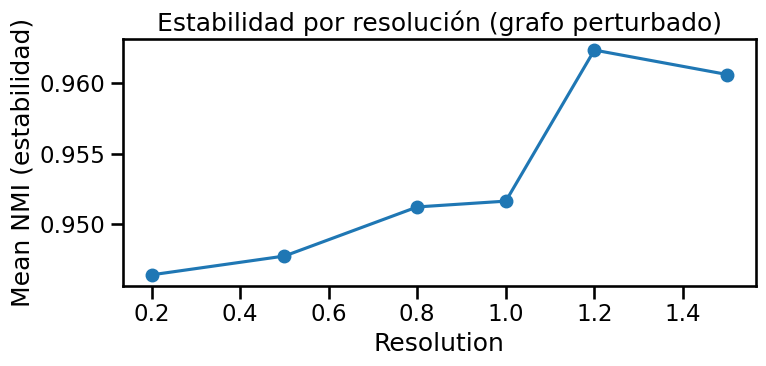

In [56]:
# =====================================================
# ✅ SELECCIÓN POR ESTABILIDAD y APLICACIÓN DE best_res
# =====================================================
stab_df, stab_assign, best_res, idx_used = run_stability_suite(
    adatas_hvg,
    resolutions=stab_resolutions,
    n_repeats=n_repeats,
    keep_prob=keep_prob,
    base_key='leiden_stab',
    random_seed=random_seed,
    use_subset=use_subset,
    max_cells=max_cells,
    neighbors_key=neighbors_key,
    verbose=True,
    save_csv_path=stability_csv
)
display(stab_df)
plt.figure(figsize=(8,4))
plt.plot(stab_df['resolution'], stab_df['stability_NMI_mean'], marker='o')
plt.xlabel('Resolution'); plt.ylabel('Mean NMI (estabilidad)'); plt.title('Estabilidad por resolución (grafo perturbado)')
plt.tight_layout(); plt.savefig(stability_pdf); plt.show()
# Último tiempo de ejecución: 332.9s


task_done_beep()

En este caso, aunque la mejor opción sería 1.2, voy a coger 0.5 porque 1.2 tiene demasiados clusters, por lo que a lo mejor puede haber problemas al comparar coding con noncoding

In [ ]:
# CHOOSE MANUALLY THE BEST RESOLUTION
best_res= 0.5

sc.tl.leiden(adatas_hvg, resolution=float(best_res), key_added='leiden_best', random_state=0)

adatas_hvg.obs['mode_celltypist'] = (adatas_hvg.obs.groupby('leiden_best')['preannotation'].transform(lambda x: x.mode()[0]))
# Calcula la moda dentro de cada cluster de leiden y añade una nueva columna 
# 


print(f"✅ Leiden final aplicado: resolution={best_res} → key='leiden_best'")


✅ Leiden final aplicado: resolution=0.5 → key='leiden_best'


In [58]:
adatas_hvg

AnnData object with n_obs × n_vars = 39966 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score', 'leiden_stab_0.2_rep0', 'leiden_stab_0.2_rep1', 'leiden_stab_0.2_rep2', 'leiden_stab_0.2_rep3', 'leiden_stab_0.2_rep4', 'leiden_stab_0.2_rep5', 'leiden_stab_0.2_rep6', 'leiden_stab_0.2_rep7', 'leiden_stab_0.5_rep0', 'leiden_stab_0.5_rep1', 'leiden_stab_0.5_rep2', 'leiden_stab_0.5_rep3', 'leiden_stab_0.5_rep4', 'leiden_stab_0.5_rep5', 'leiden_stab_0.5_rep6', 'leiden_stab_0.5_rep7', 'leiden_stab_0.8_rep0', 'leiden_stab_0.8_rep1', 'leiden_stab_0.8_rep2

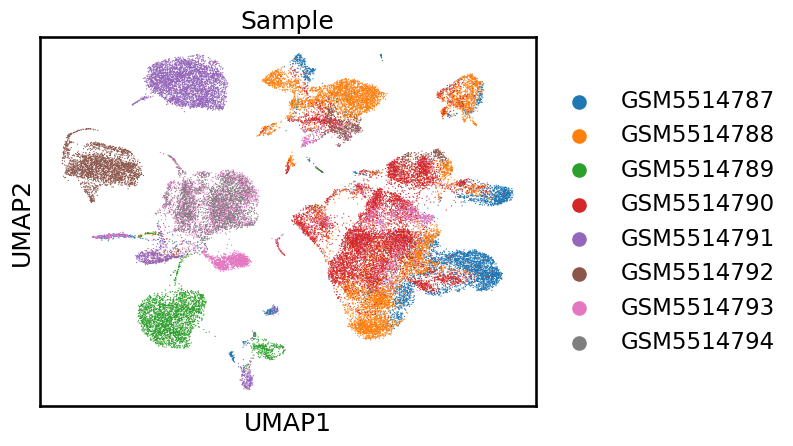

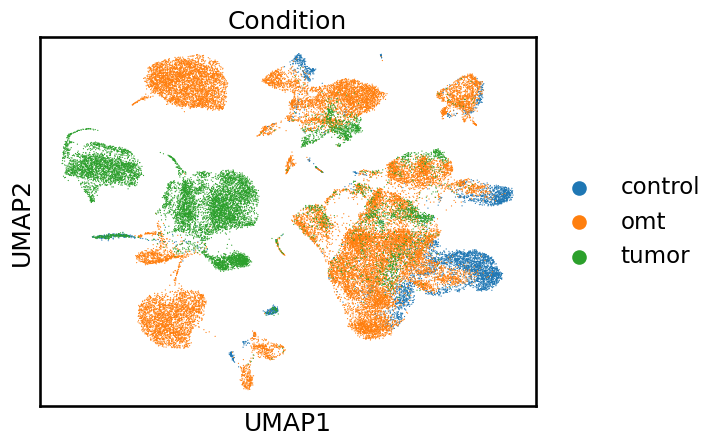

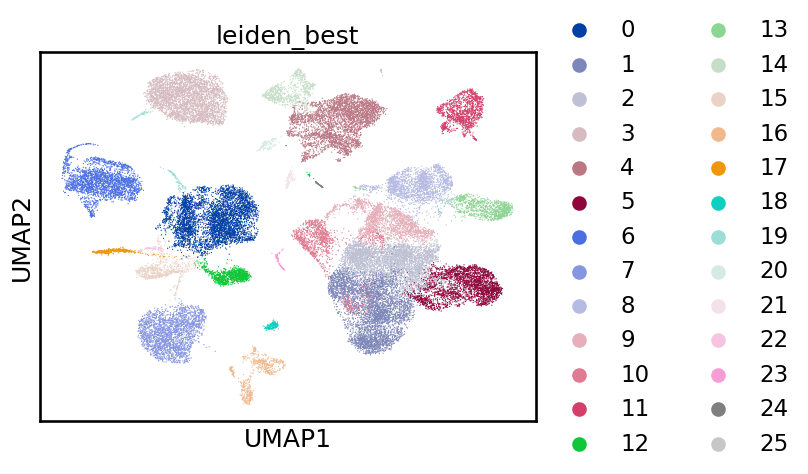

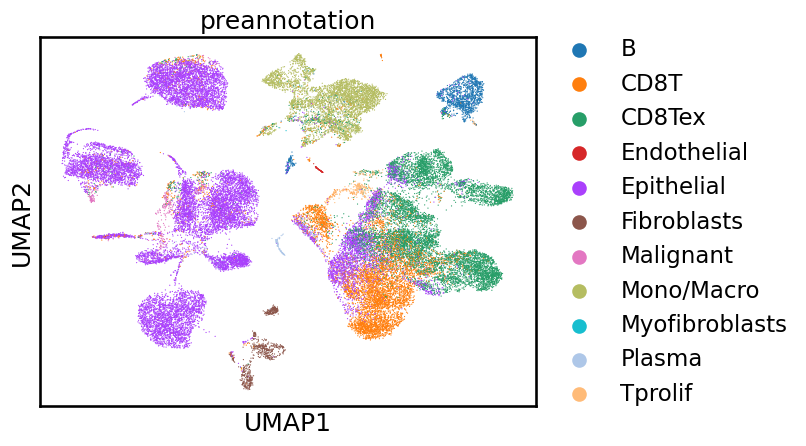

In [59]:
# PART 3 ADDED{
# sc.tl.umap(adatas_hvg, neighbors_key=neighbors_key)

sc.pl.umap(adatas_hvg, color=['Sample'])
sc.pl.umap(adatas_hvg, color=['Condition'])
sc.pl.umap(adatas_hvg, color=['leiden_best'], legend_loc='right margin')
sc.pl.umap(adatas_hvg, color=['preannotation'], legend_loc='right margin')
# }

## <span style="font-size:20px;color:dodgerblue"> **2.- With** Batch aware (scib.preprocessing.scale_batch)</span> 


<span style="font-size:25px; color:red">*RECOVERY POINT*</i></span> </br>


In [60]:
adatas_raw_hvg=sc.read("Noncoding/adatas_raw_hvg.h5ad")

In [61]:
adatas_raw_hvg

AnnData object with n_obs × n_vars = 39966 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells', 'highly_variable', 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts', 'logcounts'

In [ ]:
# ✅ USAR ESTA CELDA
batch_key = "Sample"
condition_key='Condition' # (control / lesión-tipo)
label_key = 'celltypist' # provisional label para el analisis de parámetros biologicos en integración

# Escalado batch-aware con datos preanotados
adatas_batch_aware = adatas_raw_hvg.copy()

adatas_batch_aware=scib.preprocessing.scale_batch(adatas_batch_aware, batch_key)
print("Tipo devuelto por scale_batch:", type(adatas_batch_aware))
print("Shape tras scale_batch:", adatas_batch_aware.shape)

# Dado que scale_batch puede eliminar los metadatos introducidos, los restauro en las siguientes líneas:
adatas_batch_aware = adatas_batch_aware[adatas_raw_hvg.obs_names].copy()
adatas_batch_aware.obs = adatas_raw_hvg.obs.loc[adatas_batch_aware.obs_names].copy()
print("Samples restaurados:")
print(adatas_batch_aware.obs[batch_key].value_counts())

# Dado que también puede generar algún problema en los datos debido al escalado, hay que limpiarlo también:
if sparse.issparse(adatas_batch_aware.X):
    print("NaN antes:", np.isnan(adatas_batch_aware.X.data).sum())
    print("Inf antes:", np.isinf(adatas_batch_aware.X.data).sum())

    adatas_batch_aware.X.data = np.nan_to_num(
        adatas_batch_aware.X.data,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    adatas_batch_aware.X = adatas_batch_aware.X.astype(np.float32)

    print("NaN después:", np.isnan(adatas_batch_aware.X.data).sum())
    print("Inf después:", np.isinf(adatas_batch_aware.X.data).sum())

else:
    print("NaN antes:", np.isnan(adatas_batch_aware.X).sum())
    print("Inf antes:", np.isinf(adatas_batch_aware.X).sum())

    adatas_batch_aware.X = np.nan_to_num(
        adatas_batch_aware.X,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    ).astype(np.float32)

    print("NaN después:", np.isnan(adatas_batch_aware.X).sum())
    print("Inf después:", np.isinf(adatas_batch_aware.X).sum())

# PCA sobre datos corregidos (en .X)
sc.tl.pca(adatas_batch_aware, use_highly_variable=True) # Para asegurarte de usar únicamente HVGs si no se puede con un simple: sc.tl.pca(adatas_batch_aware)

# Guardar como X_batch_aware si lo necesitas explícitamente
adatas_batch_aware.obsm["X_BAW"] = adatas_batch_aware.obsm["X_pca"].copy()

# Usar esa representación para vecinos y UMAP
sc.pp.neighbors(adatas_batch_aware, use_rep="X_BAW")
sc.tl.umap(adatas_batch_aware)

# Clustering
start=time.time()
sc.tl.leiden(adatas_batch_aware, resolution=0.5, key_added='best_res')
end=time.time()
print(f"Leiden clustering took {end - start:.2f} seconds.")


# Batch-aware scaled representation
adatas_batch_aware.write("Noncoding/adatas_raw_batch_aware.h5ad")



Tipo devuelto por scale_batch: <class 'anndata._core.anndata.AnnData'>
Shape tras scale_batch: (39966, 2000)
Samples restaurados:
Sample
GSM5514790    8706
GSM5514788    8649
GSM5514793    4959
GSM5514787    4728
GSM5514791    4313
GSM5514792    3531
GSM5514789    2971
GSM5514794    2109
Name: count, dtype: int64
NaN antes: 991894
Inf antes: 0
NaN después: 0
Inf después: 0
Leiden clustering took 14.60 seconds.


In [63]:
adatas_bm=sc.read("Noncoding/adatas_bm.h5ad")
adatas_bm

AnnData object with n_obs × n_vars = 39966 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells', 'highly_variable', 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'Unintegrated', 'X_pca'
    varm: 'PCs'
    layers: 'counts', 'logcounts'

In [ ]:
# BM metrics
adatas_bm.obsm["X_BAW"] = adatas_batch_aware.obsm["X_BAW"].copy()  # Asignar el X_pca corregido a adata


# Salvar original adatas no integrado, preanotado y con solo HVGs para comparación.
adatas_bm.write("Noncoding/adatas_bm.h5ad", compression="gzip")


In [65]:
adatas_bm

AnnData object with n_obs × n_vars = 39966 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells', 'highly_variable', 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'Unintegrated', 'X_pca', 'X_BAW'
    varm: 'PCs'
    layers: 'counts', 'logcounts'

<h4 style="color:dodgerblue;">Visualization</h4>

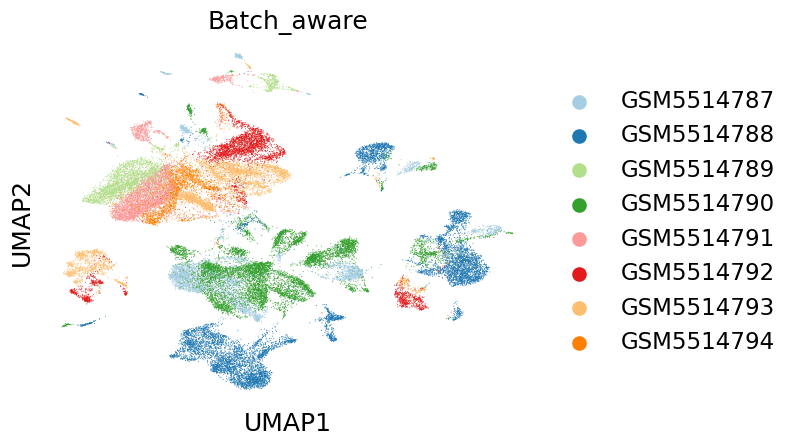

In [66]:
# ✅ USAR ESTA CELDA
unique_batches = adatas_batch_aware.obs[batch_key].nunique()
palette_viva = sns.color_palette("Paired", unique_batches)  # "tab20", "Set2", "husl", etc.

fig, ax = plt.subplots()

np.random.seed(1)
ri = np.random.permutation(list(range(adatas_batch_aware.shape[0])))

# Visualización UMAP integrado combat
sc.pl.umap(adatas_batch_aware[ri,:], color=[batch_key], vmin = .5, size = 2, ax=ax, palette=palette_viva, show=False)
plt.title('Batch_aware')
for spine in ax.spines.values():
    spine.set_visible(False)  # Elimina bordes
plt.savefig('Noncoding/Batch_aware.pdf')
plt.show()
task_done_beep()

In [ ]:
# TEST

print(np.allclose(
    adatas_unintegrated_hvg.obsm["X_umap"],
    adatas_batch_aware.obsm["X_umap"]
))

False


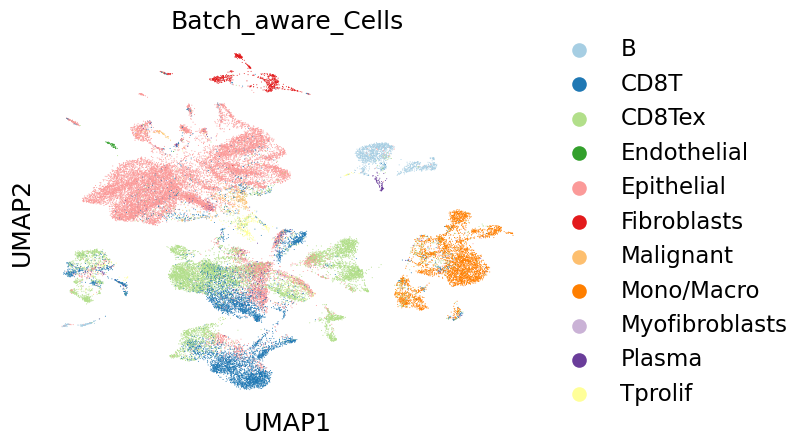

In [ ]:
cell_col = "preannotation"  # o usa label_key si ya lo definiste

# asegurar categórico y paleta
labels = adatas_batch_aware.obs[cell_col].astype("category")
adatas_batch_aware.obs[cell_col] = labels
n = len(labels.cat.categories)
palette = sns.color_palette("Paired", min(n, 12)) if n <= 12 else sns.color_palette("husl", n)



# dibujar
np.random.seed(1)
ri = np.random.permutation(adatas_batch_aware.n_obs)

fig, ax = plt.subplots()
sc.pl.umap(
    adatas_batch_aware[ri, :],
    color=cell_col,
    size=2,
    palette=palette,
    ax=ax,
    show=False,
)
ax.set_title("Batch_aware_Cells")
for s in ax.spines.values(): s.set_visible(False)
plt.savefig("Noncoding/Batch_aware_celltypist.pdf", bbox_inches="tight")
plt.show()
task_done_beep()

In [69]:
adatas_batch_aware

AnnData object with n_obs × n_vars = 39966 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score', 'best_res'
    var: 'n_cells', 'highly_variable', 'mean-0', 'std-0', 'mean-1', 'std-1', 'mean-2', 'std-2', 'mean-3', 'std-3', 'mean-4', 'std-4', 'mean-5', 'std-5', 'mean-6', 'std-6', 'mean-7', 'std-7'
    uns: 'pca', 'neighbors', 'umap', 'best_res'
    obsm: 'X_pca', 'X_BAW', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'logcounts'
    obsp: 'distances', 'connectivities'

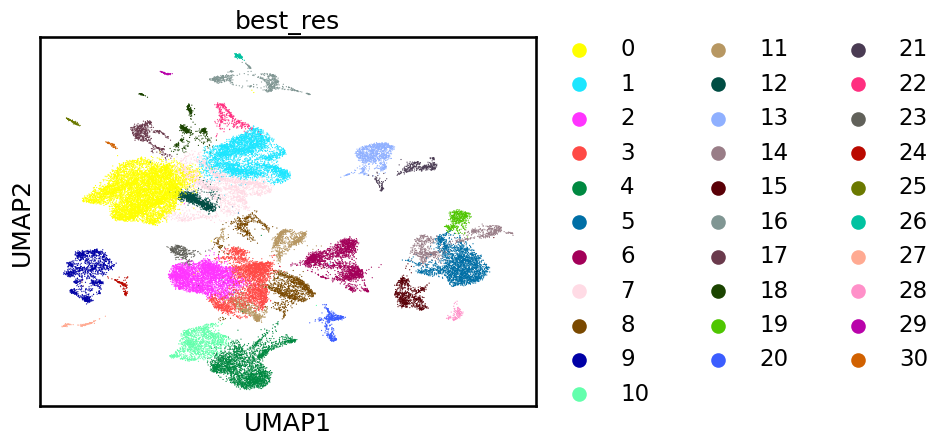

In [70]:
sc.pl.umap(adatas_batch_aware, color=['best_res'], legend_loc='right margin')


# <span style="font-size:20px;color:blue">COMBAT Integration Method</span></br>

In [ ]:
# ✅ USAR ESTA CELDA
batch_key = 'Sample'
condition_key='Condition' # (control / lesión-tipo)
# solo si se comienza de nuevo
adatas_raw_hvg = sc.read_h5ad("Noncoding/adatas_raw_hvg.h5ad") 

In [ ]:
# ✅ USAR ESTA CELDA
start = time.time()
adatas_combat = scib.integration.combat(adatas_raw_hvg, batch_key) 
end = time.time()
print(f"⏱️ TIME: {end - start:.2f} seconds.")
task_done_beep()


⏱️ TIME: 16.47 seconds.


17-5 01:26

In [73]:
# ✅ USAR ESTA CELDA
start = time.time()

# PCA sobre datos corregidos (en .X)
sc.tl.pca(adatas_combat, use_highly_variable=True) # Para asegurarte de usar únicamente HVGs si no se puede con un simple: sc.tl.pca(adatas_batch_aware)

# Guardar como X_combat si lo necesitas explícitamente
adatas_combat.obsm["X_combat"] = adatas_combat.obsm["X_pca"].copy()

# Usar esa representación para vecinos y UMAP
sc.pp.neighbors(adatas_combat, use_rep="X_combat")
sc.tl.umap(adatas_combat)

# Clustering
sc.tl.leiden(adatas_combat, resolution=0.5, key_added='best_res')

end = time.time()
print(f"Leiden clustering took {end - start:.2f} seconds.")
task_done_beep()

Leiden clustering took 98.74 seconds.


In [74]:
# ✅ USAR ESTA CELDA
adatas_combat

AnnData object with n_obs × n_vars = 39966 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score', 'best_res'
    var: 'n_cells', 'highly_variable', 'mean', 'std'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'best_res'
    obsm: 'X_pca', 'X_combat', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'logcounts'
    obsp: 'distances', 'connectivities'

In [ ]:
adatas_combat.write("Noncoding/adatas_combat.h5ad", compression="gzip")

task_done_beep()

### <span style="font-size:20px;color:dodgerblue;">Combat integration to BM metrics analysis</span>

In [76]:
adatas_bm=sc.read("Noncoding/adatas_bm.h5ad")
adatas_bm

AnnData object with n_obs × n_vars = 39966 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells', 'highly_variable', 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'Unintegrated', 'X_BAW', 'X_pca'
    varm: 'PCs'
    layers: 'counts', 'logcounts'

In [ ]:
# BM metrics
adatas_bm.obsm["X_combat"] = adatas_combat.obsm["X_pca"].copy()  # Asignar el X_pca corregido a adata


adatas_bm.write("Noncoding/adatas_bm.h5ad", compression="gzip")


In [78]:
adatas_bm

AnnData object with n_obs × n_vars = 39966 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells', 'highly_variable', 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'Unintegrated', 'X_BAW', 'X_pca', 'X_combat'
    varm: 'PCs'
    layers: 'counts', 'logcounts'

<h4 style="color:dodgerblue;">Visualization</h4>

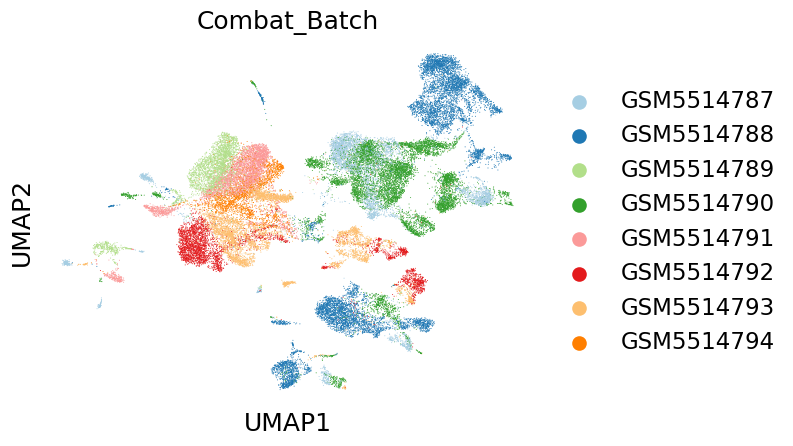

In [79]:
# ✅ USAR ESTA CELDA
unique_batches = adatas_combat.obs[batch_key].nunique()
palette_viva = sns.color_palette("Paired", unique_batches)  # "tab20", "Set2", "husl", etc.

fig, ax = plt.subplots()

np.random.seed(1)
ri = np.random.permutation(list(range(adatas_combat.shape[0])))

# Visualización UMAP integrado combat
sc.pl.umap(adatas_combat[ri,:], color=[batch_key], vmin = .5, size = 2, ax=ax, palette=palette_viva, show=False)
plt.title('Combat_Batch')
for spine in ax.spines.values():
    spine.set_visible(False)  # Elimina bordes
plt.savefig('Noncoding/adatas_combat.pdf')
plt.show()
task_done_beep()

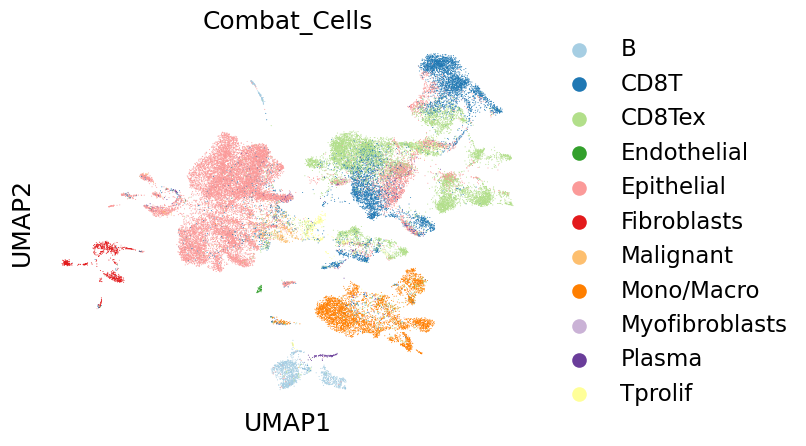

In [ ]:
cell_col = "preannotation"  # o usa label_key si ya lo definiste

# asegurar categórico y paleta
labels = adatas_combat.obs[cell_col].astype("category")
adatas_combat.obs[cell_col] = labels
n = len(labels.cat.categories)
palette = sns.color_palette("Paired", min(n, 12)) if n <= 12 else sns.color_palette("husl", n)


# dibujar
np.random.seed(1)
ri = np.random.permutation(adatas_combat.n_obs)

fig, ax = plt.subplots()
sc.pl.umap(
    adatas_combat[ri, :],
    color=cell_col,
    size=2,
    palette=palette,
    ax=ax,
    show=False,
)

ax.set_title("Combat_Cells")
for s in ax.spines.values(): s.set_visible(False)
plt.savefig("Noncoding/adatas_combat_celltypist.pdf", bbox_inches="tight")
plt.show()
task_done_beep()

# <span style="font-size:20px;color:blue">SCANORAMA Integration Method</span> </br>

<span style="color: red; fontsize: 20px"> RECOVERY POINT</span> </br>

In [81]:
# ✅ USAR ESTA CELDA
batch_key = 'Sample'
condition_key='Condition' # (control / lesión-tipo)
# sólo si se comienza de nuevo
adatas_raw_hvg = sc.read_h5ad("Noncoding/adatas_raw_hvg.h5ad") 

In [82]:
adatas_raw_hvg

AnnData object with n_obs × n_vars = 39966 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells', 'highly_variable', 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts', 'logcounts'

In [83]:
# ✅ USAR ESTA CELDA
# Escalado batch-aware
start = time.time()

print("Layers en input:", adatas_raw_hvg.layers.keys())

adatas_scanorama = scib.integration.scanorama(
    adatas_raw_hvg,
    batch_key,
    hvg=None
)
end = time.time()

print("Layers en output:", adatas_scanorama.layers.keys())

print(f"⏱️ TIME: {end - start:.2f} seconds.")
task_done_beep()

Layers en input: KeysView(Layers with keys: counts, logcounts)
Found 2000 genes among all datasets
[[0.         0.40545685 0.06092225 0.41666667 0.01252029 0.03540074
  0.15503384 0.0398293 ]
 [0.         0.         0.2046449  0.49288935 0.00231857 0.20249221
  0.09954908 0.00462481]
 [0.         0.         0.         0.02187816 0.0440929  0.145069
  0.05116123 0.01783911]
 [0.         0.         0.         0.         0.37120334 0.20957236
  0.3606708  0.00964852]
 [0.         0.         0.         0.         0.         0.07767215
  0.03385115 0.01576629]
 [0.         0.         0.         0.         0.         0.
  0.42254319 0.05352591]
 [0.         0.         0.         0.         0.         0.
  0.         0.94784258]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]]
Processing datasets (6, 7)
Processing datasets (1, 3)
Processing datasets (5, 6)
Processing datasets (0, 3)
Processing datasets (0, 1)
Processing datasets (3, 4)
Processing datasets 

In [84]:
# ¿Son iguales X_emb y X_scanorama?
same = np.allclose(
    adatas_scanorama.obsm["X_emb"],
    adatas_scanorama.obsm["X_scanorama"]
)
print("X_emb == X_scanorama ?", same)

X_emb == X_scanorama ? True


In [85]:
# Guardar ambas layers: 'counts', 'logcounts' duplica tamaño; para ahorrar conservo solo counts y recalcula logcounts cuando lo necesites.
adatas_scanorama.layers["counts"] = adatas_raw_hvg.layers["counts"].copy()
adatas_scanorama

AnnData object with n_obs × n_vars = 39966 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells', 'highly_variable', 'mean', 'std'
    obsm: 'X_pca', 'X_scanorama', 'X_emb'
    layers: 'counts'

In [86]:
# USAR ESTA CELDA
start = time.time()

# Usar esa representación para vecinos y UMAP
sc.pp.neighbors(adatas_scanorama, use_rep="X_scanorama")
sc.tl.umap(adatas_scanorama)

# Clustering
start=time.time()
sc.tl.leiden(adatas_scanorama, resolution=0.5, key_added='best_res')
end=time.time()

end = time.time()
print(f"Leiden clustering took {end - start:.2f} seconds.") # TIME:
task_done_beep()

Leiden clustering took 8.16 seconds.


In [87]:
# ✅ USAR ESTA CELDA
adatas_scanorama
# Guardar ambas layers: 'counts', 'logcounts' duplica tamaño; para ahorrar conservo solo counts y recalcula logcounts cuando lo necesites.

AnnData object with n_obs × n_vars = 39966 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score', 'best_res'
    var: 'n_cells', 'highly_variable', 'mean', 'std'
    uns: 'neighbors', 'umap', 'best_res'
    obsm: 'X_pca', 'X_scanorama', 'X_emb', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [88]:
adatas_scanorama.write("Noncoding/adatas_scanorama.h5ad", compression="gzip")

## <span style="font-size:20px;color:dodgerblue;">Scanorama integration to BM metrics analysis</span>

In [89]:
# SOLO EJECUTAR ESTO SI HAS EMPEZADO DESDE EL PUNTO DE RECUPERACIÓN DE SCANORAMA, YA QUE NO TENGO TODAVÍA EL adatas_bm EN EL ENTORNO
adatas_bm=sc.read("Noncoding/adatas_bm.h5ad")
adatas_bm

AnnData object with n_obs × n_vars = 39966 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells', 'highly_variable', 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'Unintegrated', 'X_BAW', 'X_combat', 'X_pca'
    varm: 'PCs'
    layers: 'counts', 'logcounts'

In [ ]:
# BM metrics
adatas_bm.obsm["X_scanorama"] = adatas_scanorama.obsm["X_scanorama"].copy()  # Asignar el X_pca corregido a adata

adatas_bm.write("Noncoding/adatas_bm.h5ad", compression="gzip")


In [91]:
adatas_bm

AnnData object with n_obs × n_vars = 39966 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells', 'highly_variable', 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'Unintegrated', 'X_BAW', 'X_combat', 'X_pca', 'X_scanorama'
    varm: 'PCs'
    layers: 'counts', 'logcounts'

#### <span style="font-size:16px;color:deepskyblue">Visualización</span>

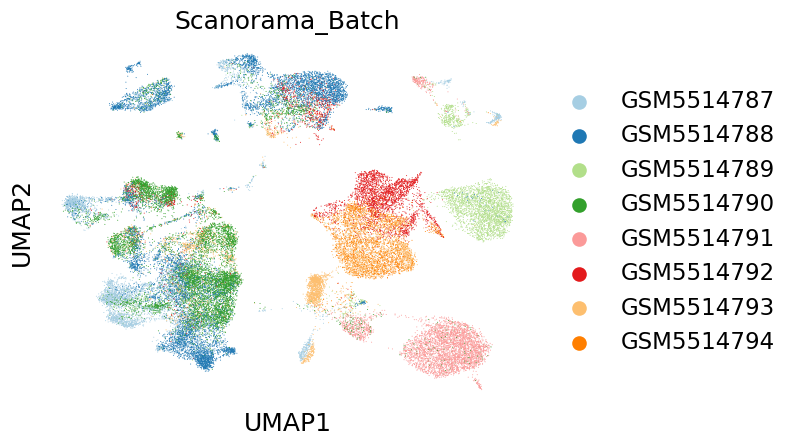

In [92]:
# ✅ USAR ESTA CELDA
unique_batches = adatas_scanorama.obs[batch_key].nunique()
palette_viva = sns.color_palette("Paired", unique_batches)  # "tab20", "Set2", "husl", etc.

fig, ax = plt.subplots()

np.random.seed(1)
ri = np.random.permutation(list(range(adatas_scanorama.shape[0])))

# Visualización UMAP integrado Scanorama
sc.pl.umap(adatas_scanorama[ri,:], color=[batch_key], vmin = .5, size = 2, ax=ax, palette=palette_viva, show=False)
plt.title('Scanorama_Batch')
for spine in ax.spines.values():
    spine.set_visible(False)  # Elimina bordes
plt.savefig('Noncoding/adatas_scanorama.pdf')
plt.show()
task_done_beep()

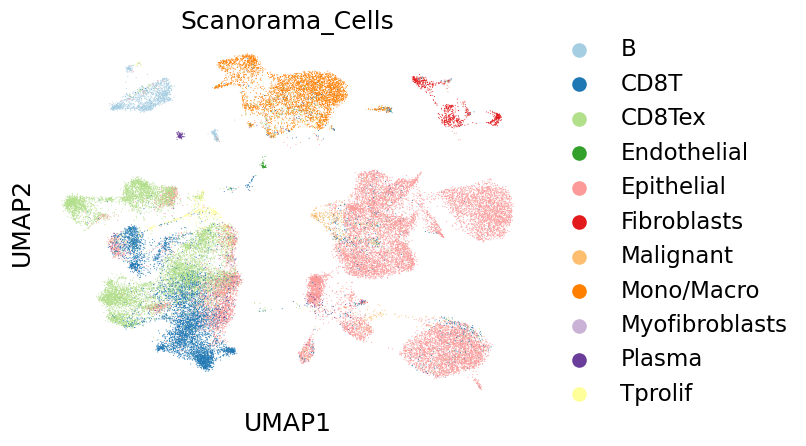

In [93]:
cell_col = "preannotation"  # "celltypist"

# asegurar categórico y contar clases
labels = adatas_scanorama.obs[cell_col].astype("category")
adatas_scanorama.obs[cell_col] = labels
n = len(labels.cat.categories)

# paleta (Paired tiene hasta 12 tonos; si hay más, usa husl)
palette = sns.color_palette("Paired", min(n, 12)) if n <= 12 else sns.color_palette("husl", n)

# orden aleatorio para dibujar
np.random.seed(1)
ri = np.random.permutation(adatas_scanorama.n_obs)

fig, ax = plt.subplots()
sc.pl.umap(
    adatas_scanorama[ri, :],
    color=cell_col,
    size=2,
    palette=palette,
    ax=ax,
    show=False
)
ax.set_title("Scanorama_Cells")
for s in ax.spines.values(): s.set_visible(False)
plt.savefig("Noncoding/adatas_scanorama_celltypist.pdf", bbox_inches="tight")
plt.show()
task_done_beep()

# <span style="font-size:20px;color:blue">Harmony Integration Method</span></br>

In [94]:
# ✅ USAR ESTA CELDA
batch_key = 'Sample'
condition_key='Condition' # (control / lesión-tipo)
# sólo si se comienza de nuevo
adatas_raw_hvg = sc.read_h5ad("Noncoding/adatas_raw_hvg.h5ad") 
adatas_harmony = adatas_raw_hvg.copy()

In [95]:
adatas_harmony

AnnData object with n_obs × n_vars = 39966 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells', 'highly_variable', 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts', 'logcounts'

In [ ]:
# ✅ USAR ESTA CELDA
start = time.time()

# scaling estándar global
sc.pp.scale(adatas_harmony)

# Harmony
adatas_harmony = scib.integration.harmony(adatas_harmony, batch_key)
end = time.time()
print(f"⏱️ TIME: {end - start:.2f} seconds.") 
task_done_beep()

	Initialization is completed.
	Completed 1 / 10 iteration(s).
	Completed 2 / 10 iteration(s).
	Completed 3 / 10 iteration(s).
	Completed 4 / 10 iteration(s).
Reach convergence after 4 iteration(s).
⏱️ TIME: 37.36 seconds.


In [97]:
adatas_harmony

AnnData object with n_obs × n_vars = 39966 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells', 'highly_variable', 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'X_pca', 'X_emb'
    varm: 'PCs'
    layers: 'counts', 'logcounts'

In [98]:
# Dado que usando scib.integration.harmony me coloca la representación integrada en X_emb en vez de en X_pca_harmony, creo X_pca_harmony manualmente con los datos de X_emb
adatas_harmony.obsm["X_pca_harmony"] = adatas_harmony.obsm["X_emb"].copy()
adatas_harmony

AnnData object with n_obs × n_vars = 39966 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells', 'highly_variable', 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'X_pca', 'X_emb', 'X_pca_harmony'
    varm: 'PCs'
    layers: 'counts', 'logcounts'

In [ ]:
# USAR ESTA CELDA
start = time.time()

# Guardar como X_harmony si lo necesitas explícitamente
adatas_harmony.obsm["X_harmony"] = adatas_harmony.obsm["X_pca_harmony"].copy() # Revisar por que cada wrapper lo guarda de un modo check "X_emb"
# ¿Son iguales X_emb y X_harmony?
same = np.allclose(adatas_harmony.obsm["X_emb"], adatas_harmony.obsm["X_pca"])
print("X_emb == X_pca ?", same)

# Usar esa representación para vecinos y UMAP
sc.pp.neighbors(adatas_harmony, use_rep="X_harmony")
sc.tl.umap(adatas_harmony)

# Clustering
sc.tl.leiden(adatas_harmony, resolution=0.5, key_added='best_res')

end = time.time()
print(f"Leiden clustering took {end - start:.2f} seconds.") # TIME: 1168.52 secs

task_done_beep()

X_emb == X_pca ? False
Leiden clustering took 55.35 seconds.


In [100]:
# ✅ USAR ESTA CELDA
adatas_harmony

AnnData object with n_obs × n_vars = 39966 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score', 'best_res'
    var: 'n_cells', 'highly_variable', 'mean', 'std'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'best_res'
    obsm: 'X_pca', 'X_emb', 'X_pca_harmony', 'X_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'logcounts'
    obsp: 'distances', 'connectivities'

In [101]:
adatas_harmony.write("Noncoding/adatas_harmony.h5ad", compression="gzip")

<h4 style="color:deepskyblue;">Harmony BM</h4>

In [102]:
# SOLO EJECUTAR ESTO SI HAS EMPEZADO DESDE EL PUNTO DE RECUPERACIÓN DE SCANORAMA, YA QUE NO TENGO TODAVÍA EL adatas_bm EN EL ENTORNO
adatas_bm=sc.read("Noncoding/adatas_bm.h5ad")
adatas_bm

AnnData object with n_obs × n_vars = 39966 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells', 'highly_variable', 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'Unintegrated', 'X_BAW', 'X_combat', 'X_pca', 'X_scanorama'
    varm: 'PCs'
    layers: 'counts', 'logcounts'

In [ ]:
# ✅ USAR ESTA CELDA
start = time.time()

# BM metrics
adatas_bm.obsm["X_harmony"] = adatas_harmony.obsm["X_pca_harmony"].copy()

adatas_bm.write("Noncoding/adatas_bm.h5ad", compression="gzip")
end = time.time()

task_done_beep()

In [104]:
adatas_bm

AnnData object with n_obs × n_vars = 39966 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells', 'highly_variable', 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'Unintegrated', 'X_BAW', 'X_combat', 'X_pca', 'X_scanorama', 'X_harmony'
    varm: 'PCs'
    layers: 'counts', 'logcounts'

In [105]:
# Inicializar diccionario para guardar resultados de las métricas SCIB
results_harmony = {}

#### <span style="font-size:16px;color:deepskyblue">Visualización</span>

Repetir esto pero con la paleta de visualizaciones anteriores </br>
Asegurarme que todas las visualizaciones estén con el mismo código

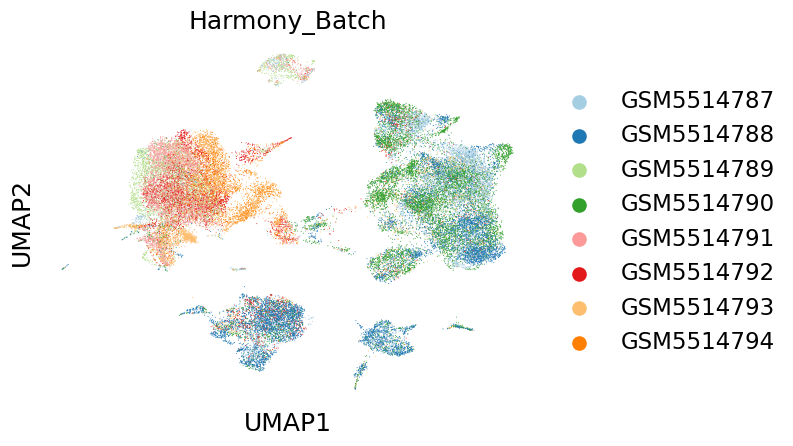

In [106]:
# ✅ USAR ESTA CELDA
unique_batches = adatas_harmony.obs[batch_key].nunique()
palette_viva = sns.color_palette("Paired", unique_batches)  # "tab20", "Set2", "husl", etc.

fig, ax = plt.subplots()

np.random.seed(1)
ri = np.random.permutation(list(range(adatas_harmony.shape[0])))

# Visualización UMAP integrado Scanorama
sc.pl.umap(adatas_harmony[ri,:], color=[batch_key], vmin = .5, size = 2, ax=ax, palette=palette_viva, show=False)
plt.title('Harmony_Batch')
for spine in ax.spines.values():
    spine.set_visible(False)  # Elimina bordes
plt.savefig('Noncoding/adatas_harmony.pdf')
plt.show()
task_done_beep()

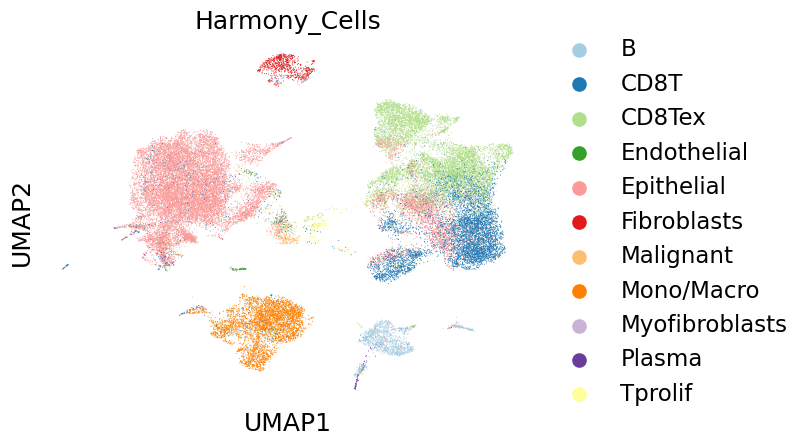

In [107]:
cell_col = "preannotation"  # "celltypist"

# asegurar categórico y contar clases
labels = adatas_harmony.obs[cell_col].astype("category")
adatas_harmony.obs[cell_col] = labels
n = len(labels.cat.categories)

# paleta (Paired tiene hasta 12 tonos; si hay más, usa husl)
palette = sns.color_palette("Paired", min(n, 12)) if n <= 12 else sns.color_palette("husl", n)

# orden aleatorio para dibujar
np.random.seed(1)
ri = np.random.permutation(adatas_harmony.n_obs)

fig, ax = plt.subplots()
sc.pl.umap(
    adatas_harmony[ri, :],
    color=cell_col,
    size=2,
    palette=palette,
    ax=ax,
    show=False
)
ax.set_title("Harmony_Cells")
for s in ax.spines.values(): s.set_visible(False)
plt.savefig("Noncoding/adatas_harmony_celltypist.pdf", bbox_inches="tight")
plt.show()
task_done_beep()

# <span style="fontsize:20px; color:blue">BENCHMARKING</span>

<span style="color:red; fontsize:20px"> RECOVERY POINT </span> </br>


In [108]:
# SOLO EJECUTAR ESTO SI HAS EMPEZADO DESDE EL PUNTO DE RECUPERACIÓN DE SCANORAMA, YA QUE NO TENGO TODAVÍA EL adatas_bm EN EL ENTORNO
adatas_bm=sc.read("Noncoding/adatas_bm.h5ad")
adatas_bm

AnnData object with n_obs × n_vars = 39966 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells', 'highly_variable', 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'Unintegrated', 'X_BAW', 'X_combat', 'X_harmony', 'X_pca', 'X_scanorama'
    varm: 'PCs'
    layers: 'counts', 'logcounts'

In [109]:
start=time.time()

bm = Benchmarker(
    adatas_bm,
    batch_key="Sample",
    label_key="preannotation",
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),
    embedding_obsm_keys=["Unintegrated", "X_BAW", "X_combat", "X_harmony", "X_scanorama"],
    n_jobs=5,
)
bm.benchmark()

end = time.time()
print(f"Benchmarker took {end - start:.2f} seconds.") # TIME: 1168.52 secs


INFO     Myofibroblasts consists of a single batch or is too small. Skip.                                          
INFO     Myofibroblasts consists of a single batch or is too small. Skip.                                          
INFO     Myofibroblasts consists of a single batch or is too small. Skip.                                          
INFO     Myofibroblasts consists of a single batch or is too small. Skip.                                          
INFO     Myofibroblasts consists of a single batch or is too small. Skip.                                          
Benchmarker took 1588.33 seconds.


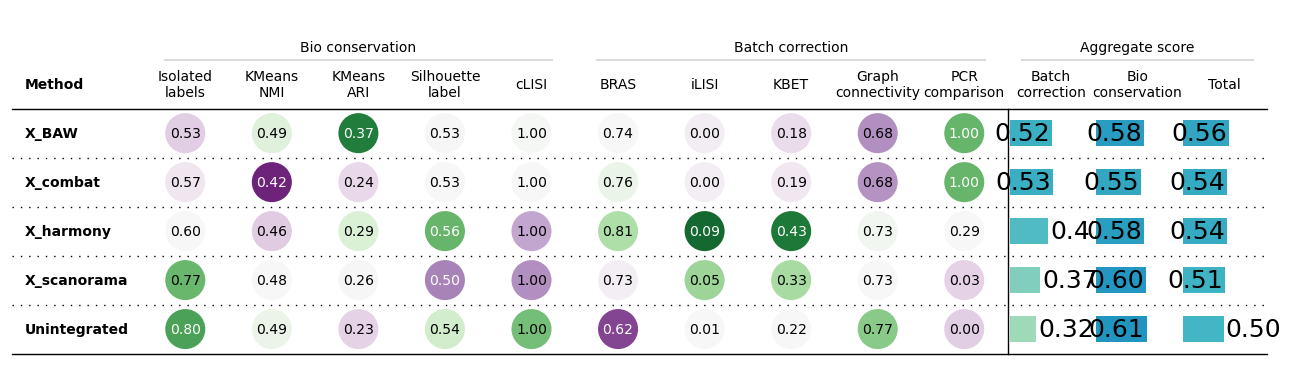

In [110]:
bm.plot_results_table()

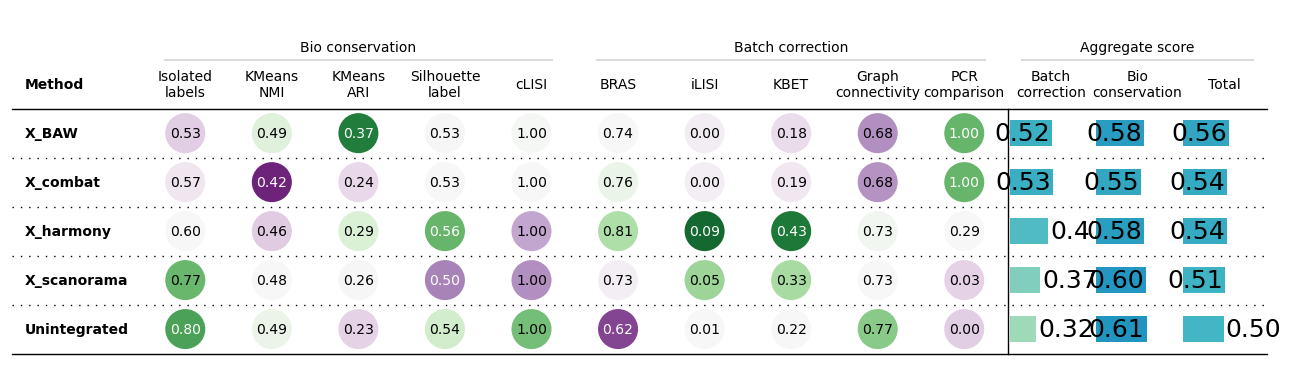

In [111]:
bm.plot_results_table(min_max_scale=False)

In [112]:
from rich import print

df = bm.get_results(min_max_scale=False)
print(df)

Isolated labels        KMeans NMI        KMeans ARI  \
Embedding                                                            
Unintegrated          0.798492          0.487822          0.231832   
X_BAW                 0.525405          0.493917          0.368155   
X_combat               0.56774          0.418802          0.236153   
X_harmony             0.598139          0.463971          0.285865   
X_scanorama           0.773103          0.482038          0.260467   
Metric Type   Bio conservation  Bio conservation  Bio conservation   

              Silhouette label             cLISI              BRAS  \
Embedding                                                            
Unintegrated          0.539605          0.997343          0.618529   
X_BAW                 0.526355          0.996902          0.742909   
X_combat              0.526606          0.996891          0.756679   
X_harmony             0.558202          0.996551          0.805501   
X_scanorama           0.497436          0.996473           0.73377   
Metric Type   Bio conservation  Bio conservation  Batch correction   

                         iLISI              KBET Graph connectivity  \
Embedding                                                             
Unintegrated          0.008047          0.218453           0.773883   
X_BAW                 0.002275          0.177126           0.677253   
X_combat              0.003024           0.19395           0.679144   
X_harmony             0.090383          0.433653           0.729815   
X_scanorama           0.048879          0.325178           0.725904   
Metric Type   Batch correction  Batch correction   Batch correction   

                PCR comparison Batch correction Bio conservation  \
Embedding                                                          
Unintegrated               0.0         0.323782         0.611019   
X_BAW                      1.0         0.519913         0.582147   
X_combat              0.999993         0.526558         0.549239   
X_harmony              0.28996         0.469863         0.580546   
X_scanorama           0.031712         0.373089         0.601903   
Metric Type   Batch correction  Aggregate score  Aggregate score   

                        Total  
Embedding                      
Unintegrated         0.496124  
X_BAW                0.557253  
X_combat             0.540166  
X_harmony            0.536272  
X_scanorama          0.510377  
Metric Type   Aggregate score

In [113]:
df.transpose()

Embedding,Unintegrated,X_BAW,X_combat,X_harmony,X_scanorama,Metric Type
Isolated labels,0.798492,0.525405,0.56774,0.598139,0.773103,Bio conservation
KMeans NMI,0.487822,0.493917,0.418802,0.463971,0.482038,Bio conservation
KMeans ARI,0.231832,0.368155,0.236153,0.285865,0.260467,Bio conservation
Silhouette label,0.539605,0.526355,0.526606,0.558202,0.497436,Bio conservation
cLISI,0.997343,0.996902,0.996891,0.996551,0.996473,Bio conservation
BRAS,0.618529,0.742909,0.756679,0.805501,0.73377,Batch correction
iLISI,0.008047,0.002275,0.003024,0.090383,0.048879,Batch correction
KBET,0.218453,0.177126,0.19395,0.433653,0.325178,Batch correction
Graph connectivity,0.773883,0.677253,0.679144,0.729815,0.725904,Batch correction
PCR comparison,0.0,1.0,0.999993,0.28996,0.031712,Batch correction


### <span style="font-size:30px;color:blue">Final integration + DGE</span> </br> <span style="font-size:14px; color:black">  
Elegir aquí cuál sería el mejor método de integración según el apartado anterior y aplicar la integración a todos los datos
</span> 

In [5]:
adatas_raw=sc.read("Noncoding/adatas_raw.h5ad")

In [6]:
adatas_raw

AnnData object with n_obs × n_vars = 39966 × 47611
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells', 'highly_variable'
    uns: 'log1p'
    layers: 'counts', 'logcounts'

In [7]:
print(adatas_raw)
print(adatas_raw.X.min(), adatas_raw.X.max())
print(adatas_raw.layers.keys())
print(adatas_raw.obs.columns)

AnnData object with n_obs × n_vars = 39966 × 47611
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score'
    var: 'n_cells', 'highly_variable'
    uns: 'log1p'
    layers: 'counts', 'logcounts'
0.0 8.460823
KeysView(Layers with keys: counts, logcounts)
Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition',
       'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo',
       'pct_cou

In [8]:
print("Matriz logcounts:")
print(adatas_raw.layers["logcounts"].min(), adatas_raw.layers["logcounts"].max())

print("Matriz counts:")
print(adatas_raw.layers["counts"].min(), adatas_raw.layers["counts"].max())

print("Matriz X:")
print(adatas_raw.X.min(), adatas_raw.X.max())


Matriz logcounts:
0.0 8.460823
Matriz counts:
0 28349
Matriz X:
0.0 8.460823


La matriz X ya tiene los datos normalizados, por lo que no hace falta hacer nada de normalizar

In [9]:
import numpy as np
from scipy import sparse

def same_matrix(a, b):
    if sparse.issparse(a) or sparse.issparse(b):
        return (a != b).nnz == 0
    else:
        return np.array_equal(a, b)

print("X == logcounts:", same_matrix(adatas_raw.X, adatas_raw.layers["logcounts"]))
print("X type:", type(adatas_raw.X))
print("counts type:", type(adatas_raw.layers["counts"]))
print("logcounts type:", type(adatas_raw.layers["logcounts"]))

X == logcounts: True
X type: <class 'scipy.sparse._csr.csr_matrix'>
counts type: <class 'scipy.sparse._csr.csr_matrix'>
logcounts type: <class 'scipy.sparse._csr.csr_matrix'>


In [ ]:
adata_noncoding = adatas_raw.copy()

# Asegurar que X contiene logcounts no integrados
adata_noncoding.X = adata_noncoding.layers["logcounts"].copy()

In [ ]:
adatas_raw.write(
    "Noncoding/adatas_raw_noncoding_logcounts_before_combat.h5ad",
    compression="gzip"
)

A partir de aquí hacer en lightning AI, ya que no tengo suficiente memoria en el ordenador